In [1]:
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
import numpy as np
import jax
import jax.numpy as jnp
import mrcfile
import matplotlib.pyplot as plt
import napari
from pinn.cryoet_io import open_raw_data
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
    visualize_z_midslice,
    visualize_zyx_midslice,
    visualize_zyx_midslice_vs_overlay,
    _to_zyx
)
from pinn.utils import assemble_loss_history, initial_loss
from pinn.model import (
    PINN,
    WEIGHT_IN, 
    EPSILON,
    LEARNING_RATE
) 
from pinn.checkpoint_io import (
    _ensure_dir,
    save_params_bytes,
    load_state_bytes,
    save_loss_npz,
    load_loss_npz,
    find_last_state_path,
    load_checkpoint_at_step
)
from pinn.grid import (
    phi_on_cryo_grid_xyz
)
from pinn.train import create_train_state, train_step
print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]
from tqdm.notebook import trange

jax: 0.7.2
devices: [CudaDevice(id=0)]


### Load specific checkpoint

In [2]:
data_dir = "Jake_Cropped"
shape1 = "74_S1"
shape2 = "74_S2"
shape3 = "74_S3"
shape4 = "74_S4"
shape5 = "74_S5"
ori_data_path1 = f"../data/{data_dir}/{shape1}_mask.mrc"
ori_data_path2 = f"../data/{data_dir}/{shape2}_mask.mrc"
ori_data_path3 = f"../data/{data_dir}/{shape3}_mask.mrc"
ori_data_path4 = f"../data/{data_dir}/{shape4}_mask.mrc"
ori_data_path5 = f"../data/{data_dir}/{shape5}_mask.mrc"
lambda_1 = 4000000
lambda_2_list = [0, 50, 100, 150, 200, 250]
lambda_2 = 0

with mrcfile.open(ori_data_path1, permissive=True) as mrc:
    mask_data1 = np.asarray(mrc.data, dtype=np.float32)
with mrcfile.open(ori_data_path2, permissive=True) as mrc:
    mask_data2 = np.asarray(mrc.data, dtype=np.float32)
with mrcfile.open(ori_data_path3, permissive=True) as mrc:
    mask_data3 = np.asarray(mrc.data, dtype=np.float32)
with mrcfile.open(ori_data_path4, permissive=True) as mrc:
    mask_data4 = np.asarray(mrc.data, dtype=np.float32)
with mrcfile.open(ori_data_path5, permissive=True) as mrc:
    mask_data5 = np.asarray(mrc.data, dtype=np.float32)

#### ZYX Midslice vs Overlay

In [3]:
phi_pred1 = np.where(abs(phi_zyx1) < 0.4, 1, 0)
visualize_zyx_midslice_vs_overlay(mask_data1, phi_pred1, alpha=0.5, title="Original vs Predicted(pink) (|phi|<0.3) lambda_1: 9e+6, lambda_2: 70, epsilon: 0.08")
visualize_zyx_midslice(mask_data1, title="Original")

phi_pred2 = np.where(abs(phi_zyx2) < 0.4, 1, 0)
visualize_zyx_midslice_vs_overlay(mask_data2, phi_pred2, alpha=0.5, title="Original vs Predicted(pink) (|phi|<0.3) lambda_1: 9e+6, lambda_2: 70, epsilon: 0.08")
visualize_zyx_midslice(mask_data2, title="Original")

phi_pred3 = np.where(abs(phi_zyx3) < 0.4, 1, 0)
visualize_zyx_midslice_vs_overlay(mask_data3, phi_pred3, alpha=0.5, title="Original vs Predicted(pink) (|phi|<0.3) lambda_1: 9e+6, lambda_2: 70, epsilon: 0.08")
visualize_zyx_midslice(mask_data3, title="Original")

phi_pred4 = np.where(abs(phi_zyx4) < 0.4, 1, 0)
visualize_zyx_midslice_vs_overlay(mask_data4, phi_pred4, alpha=0.5, title="Original vs Predicted(pink) (|phi|<0.3) lambda_1: 9e+6, lambda_2: 70, epsilon: 0.08")
visualize_zyx_midslice(mask_data4, title="Original")

phi_pred5 = np.where(abs(phi_zyx5) < 0.4, 1, 0)
visualize_zyx_midslice_vs_overlay(mask_data5, phi_pred5, alpha=0.5, title="Original vs Predicted(pink) (|phi|<0.3) lambda_1: 9e+6, lambda_2: 70, epsilon: 0.08")
visualize_zyx_midslice(mask_data5, title="Original")

NameError: name 'phi_zyx1' is not defined

#### Surface Dice Loss

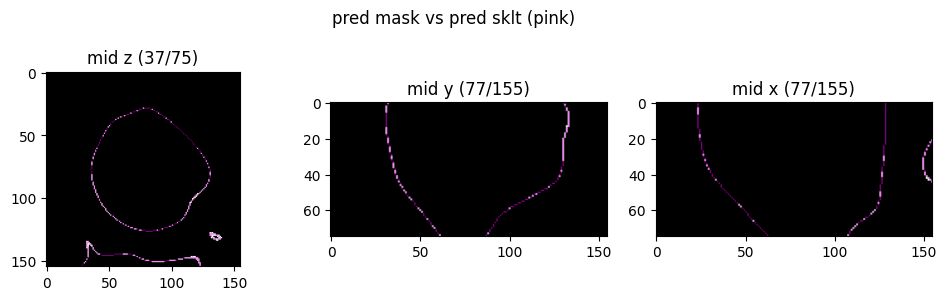

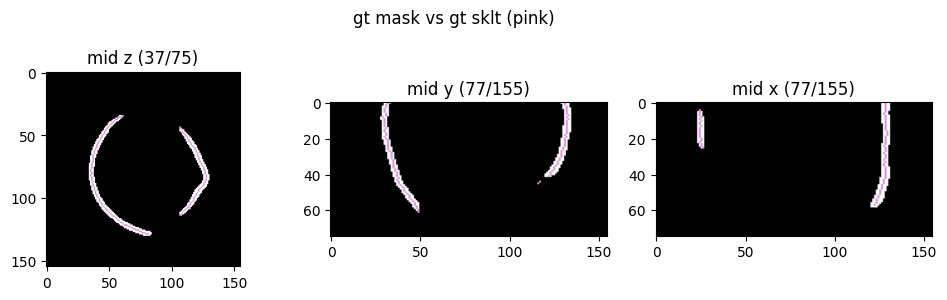

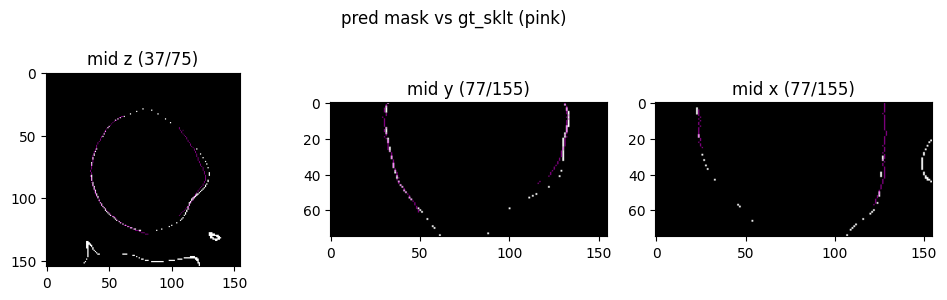

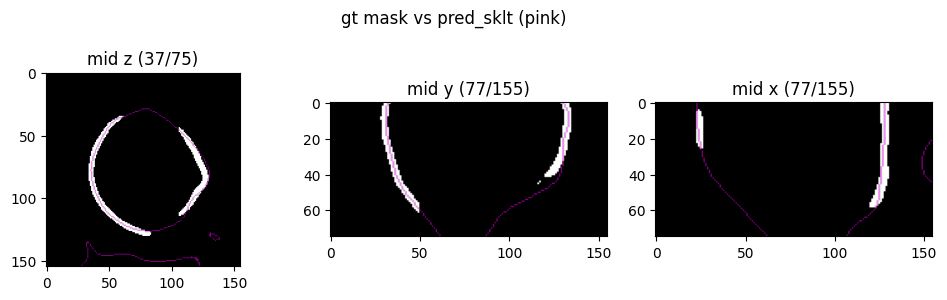

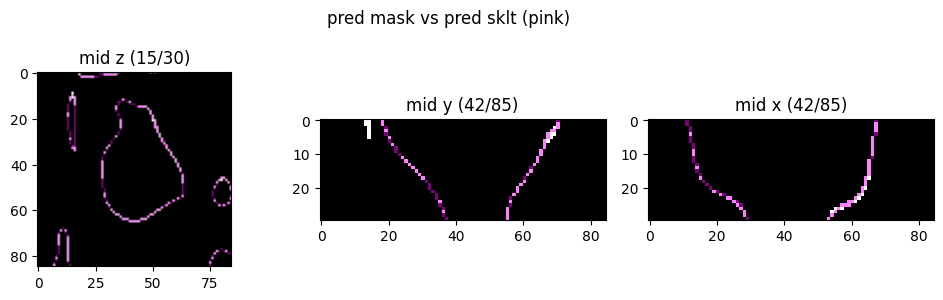

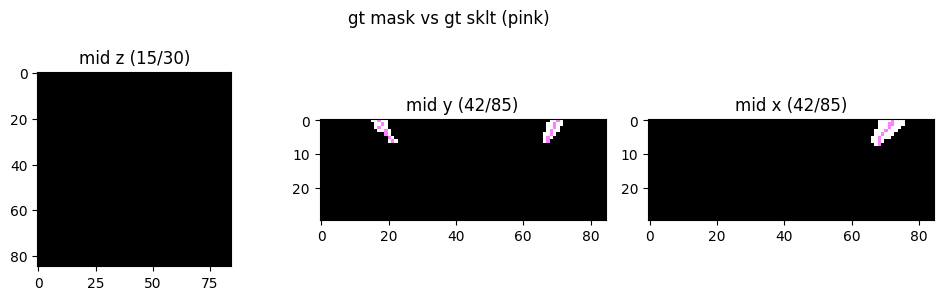

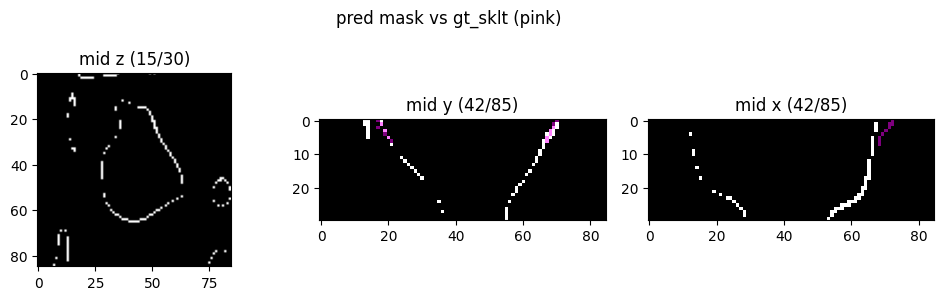

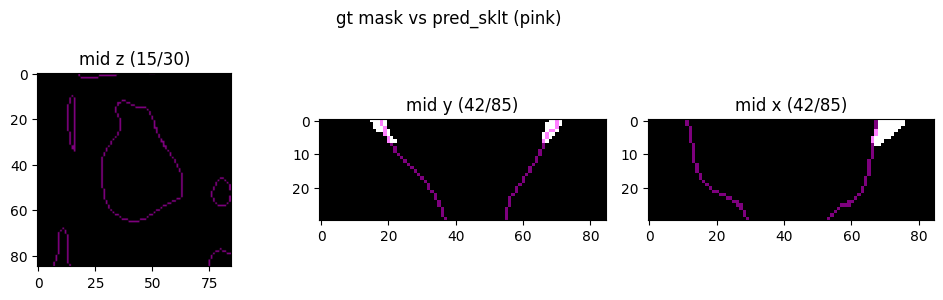

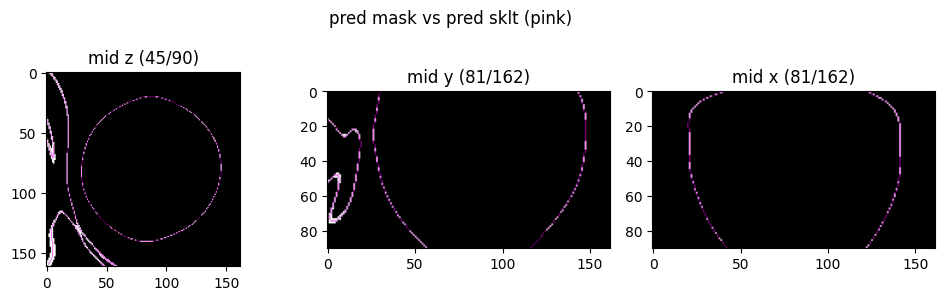

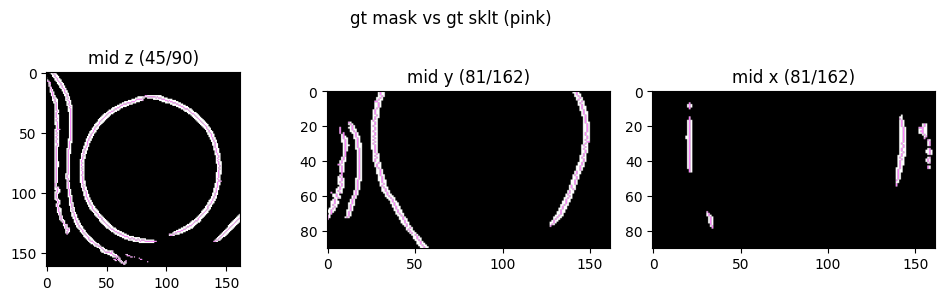

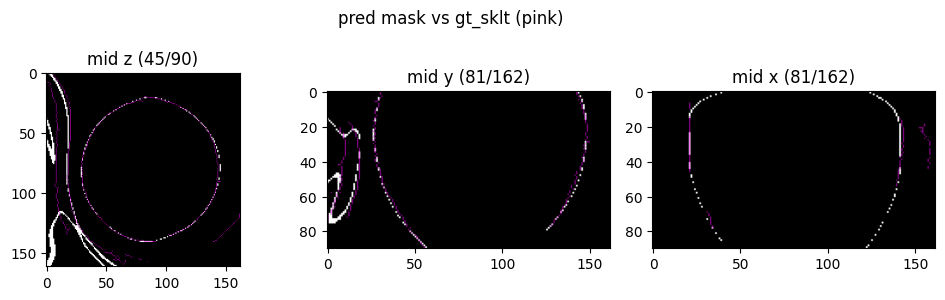

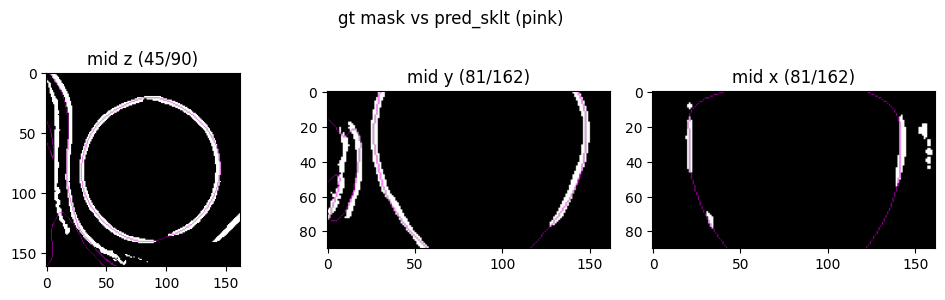

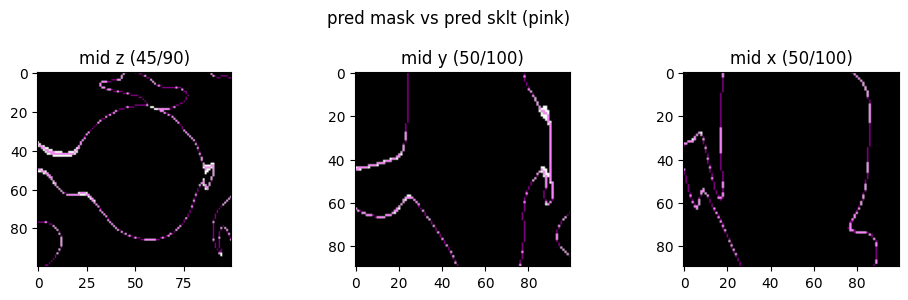

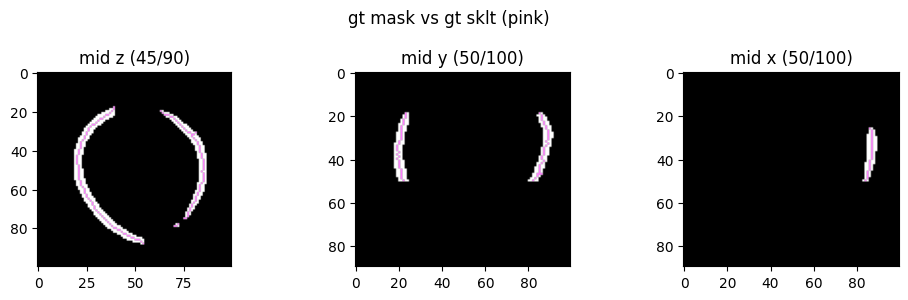

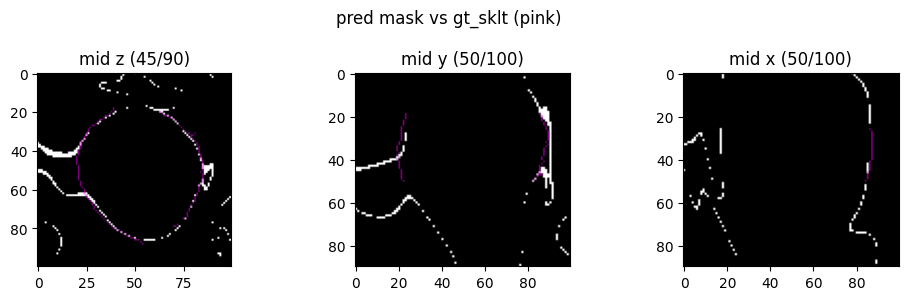

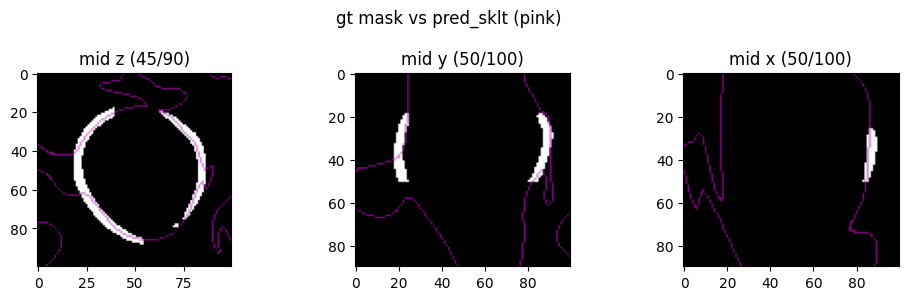

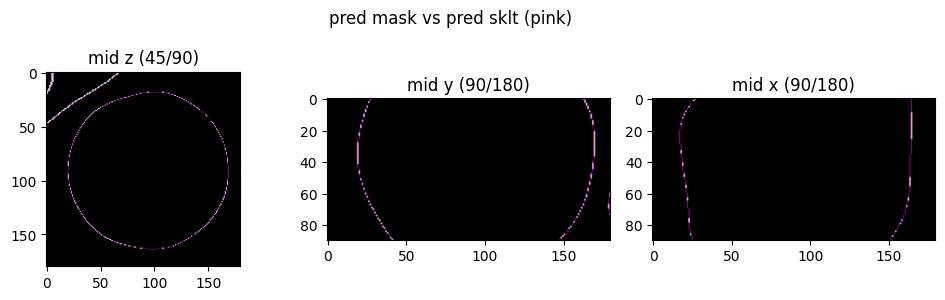

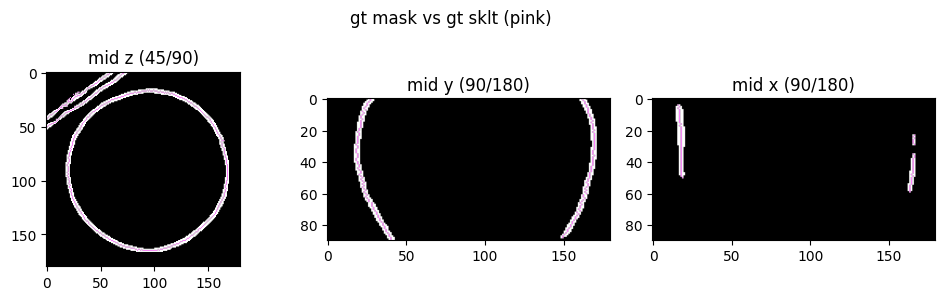

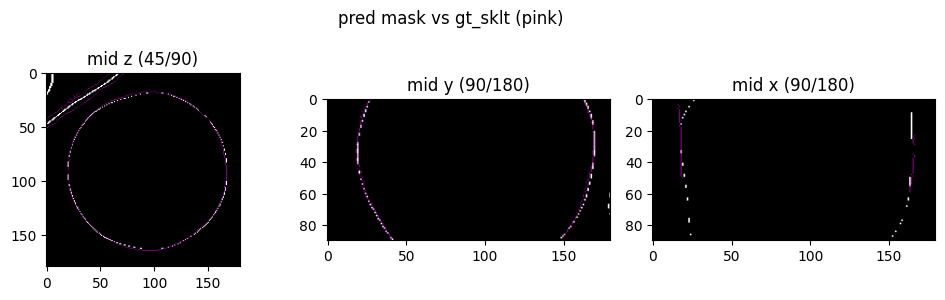

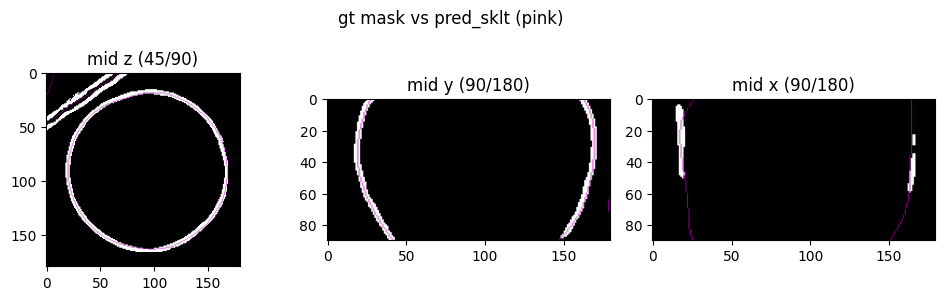

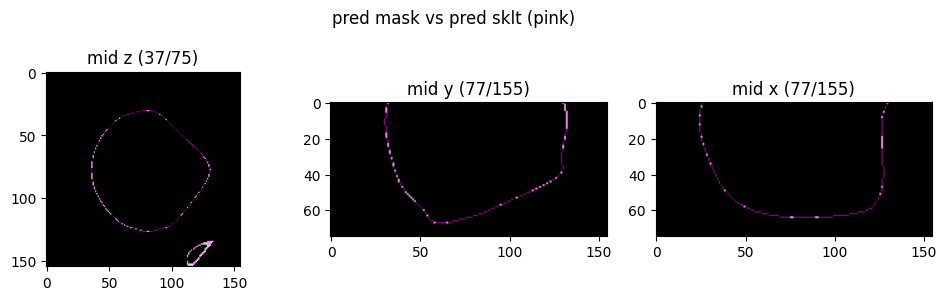

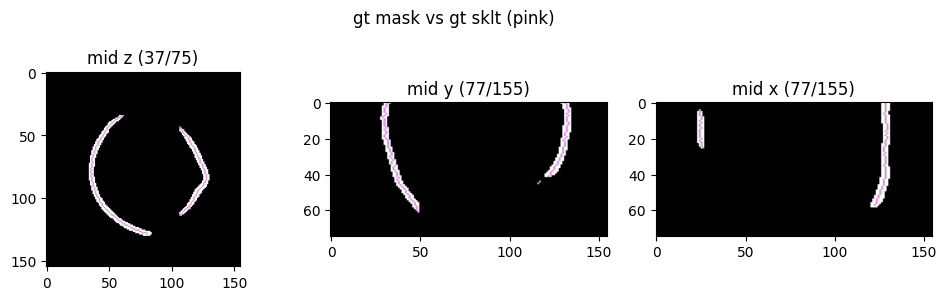

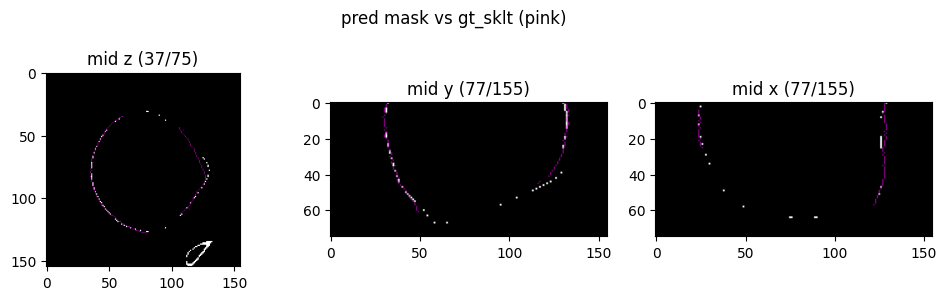

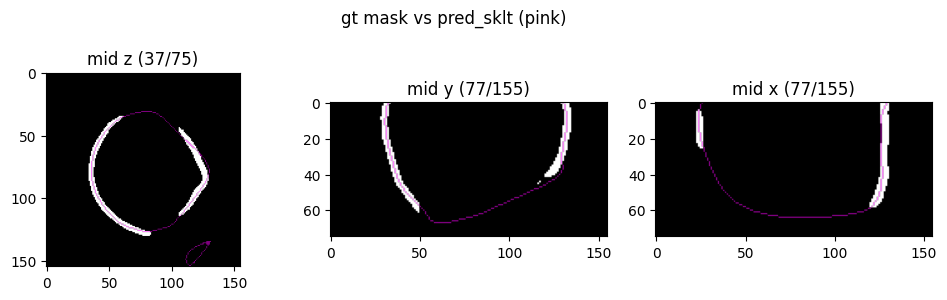

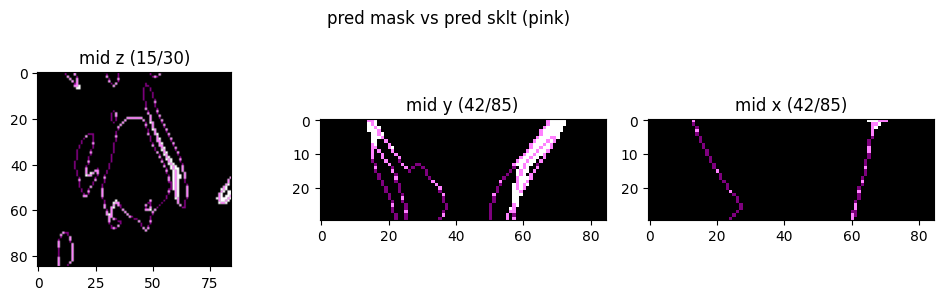

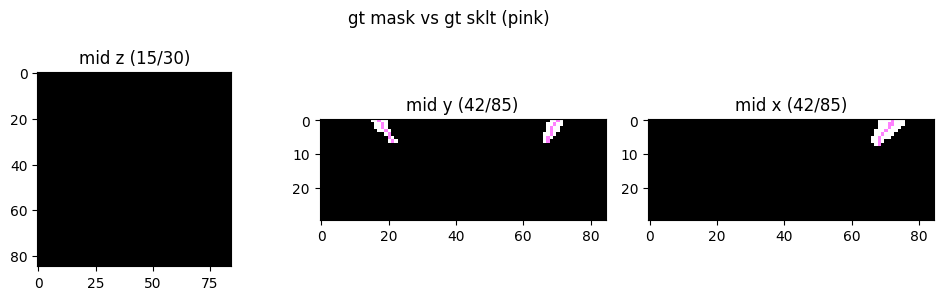

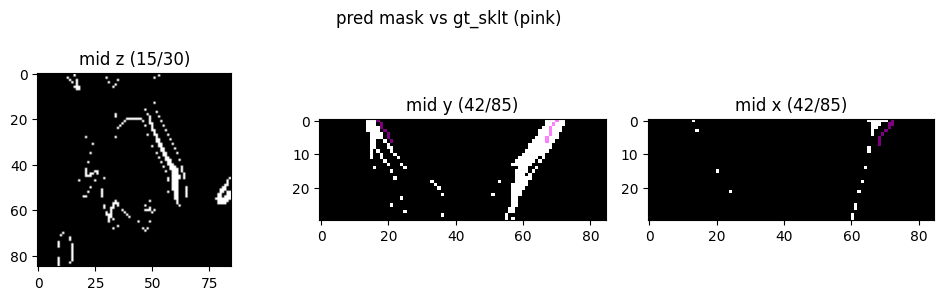

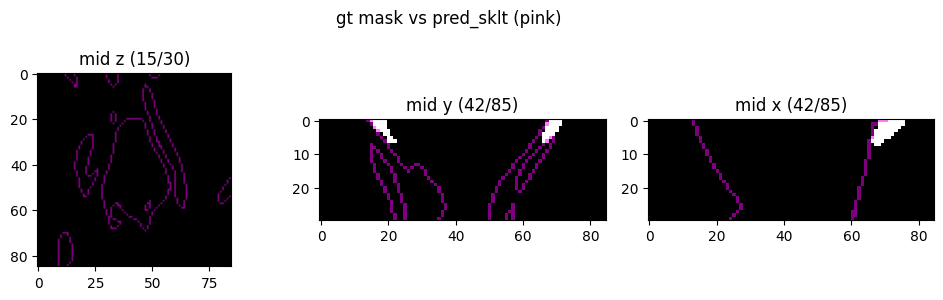

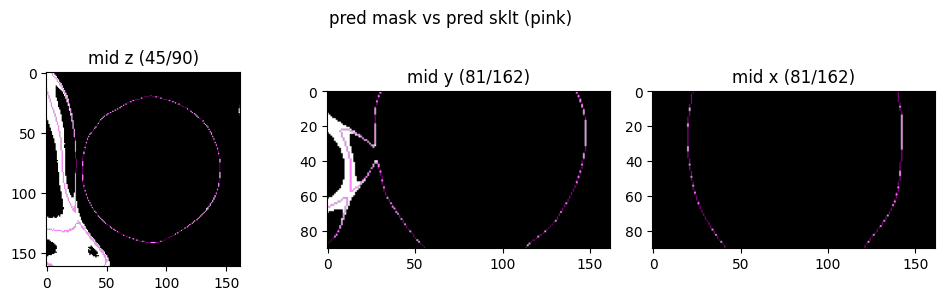

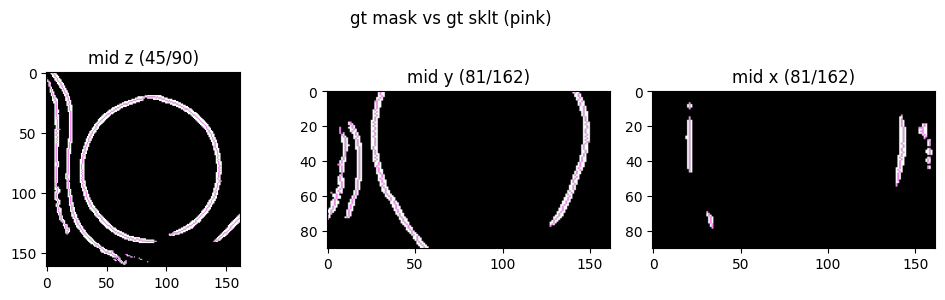

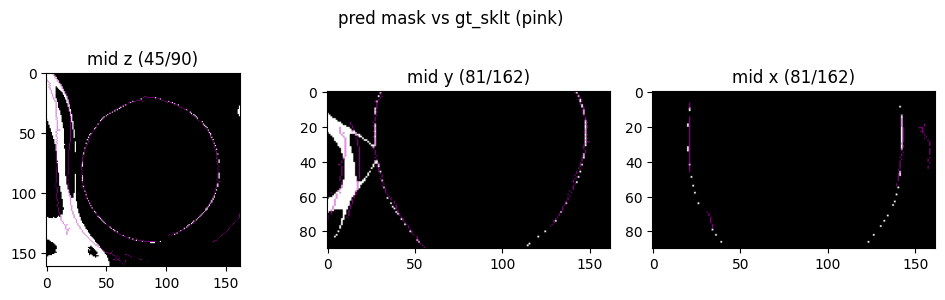

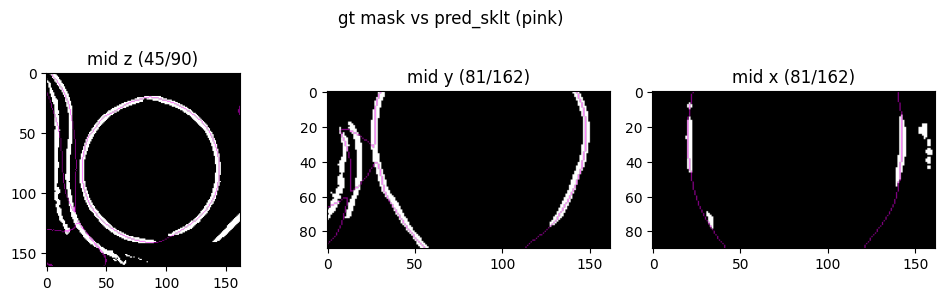

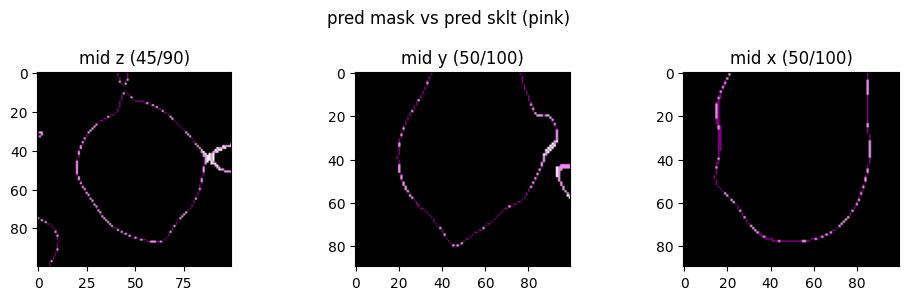

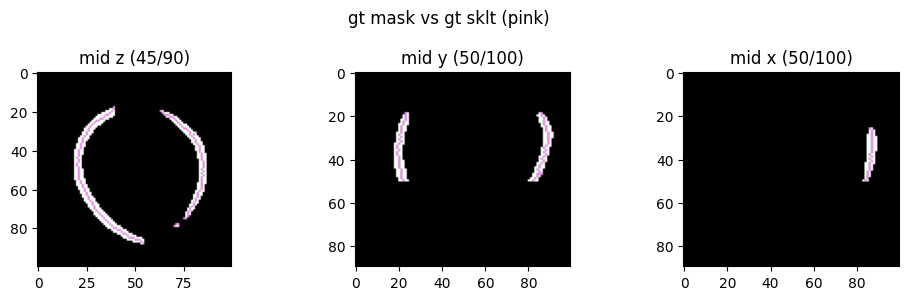

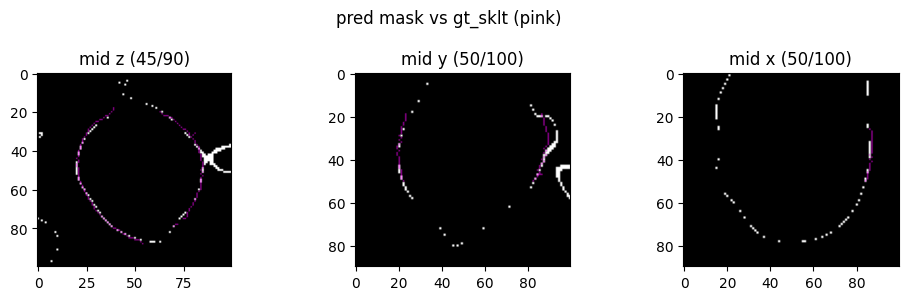

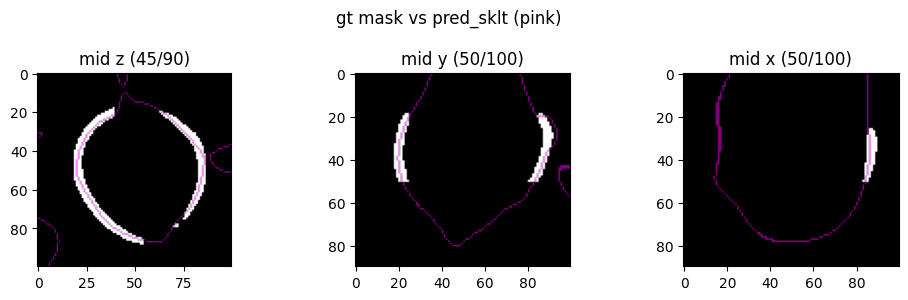

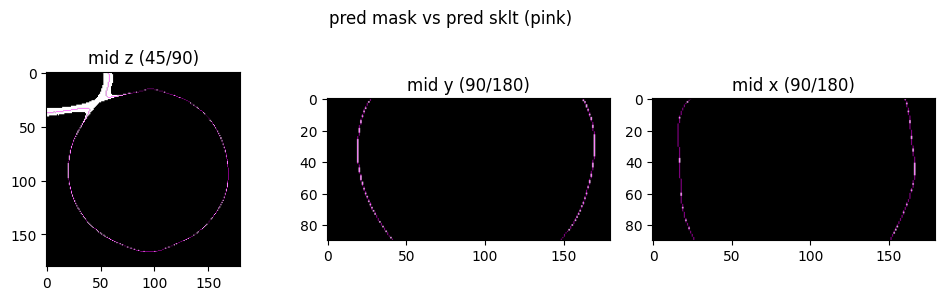

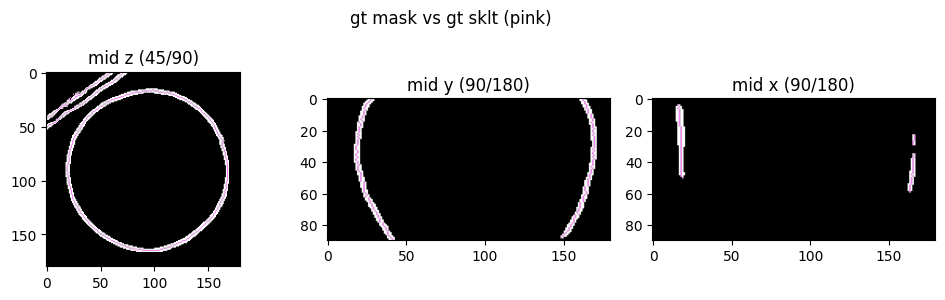

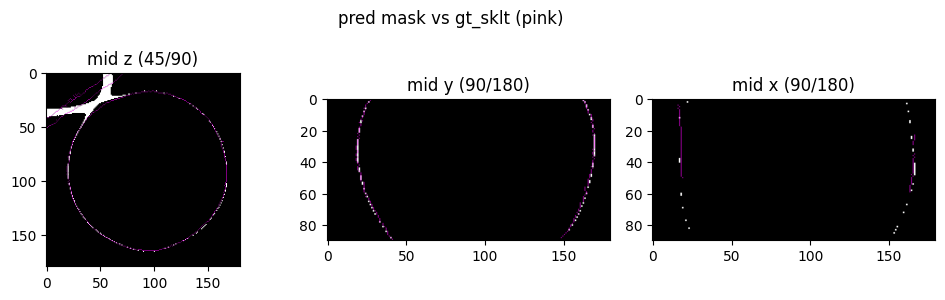

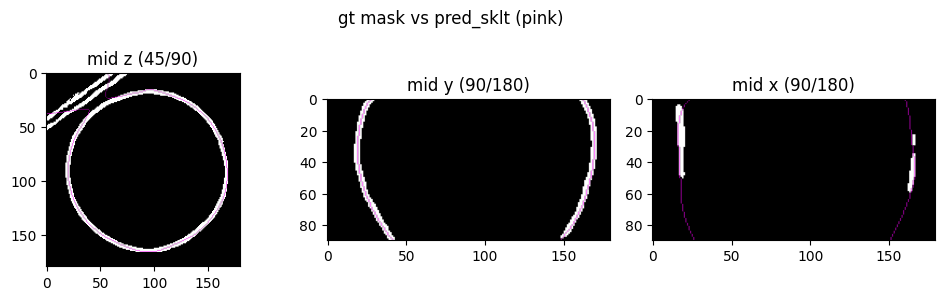

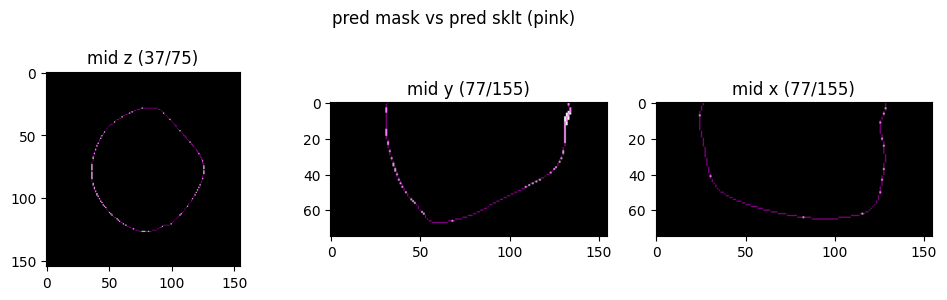

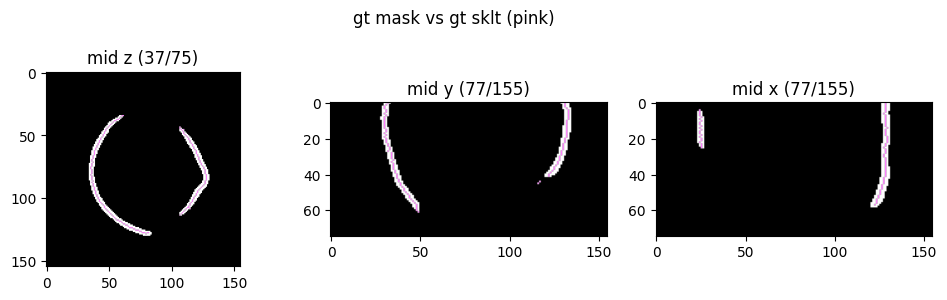

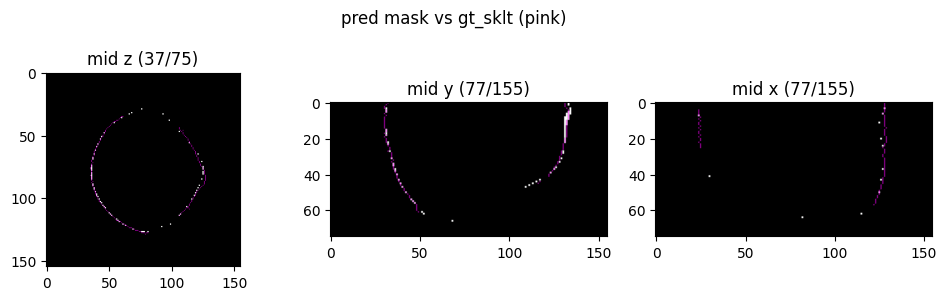

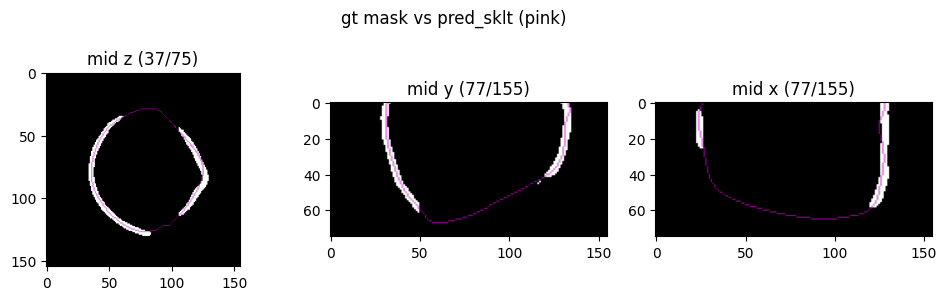

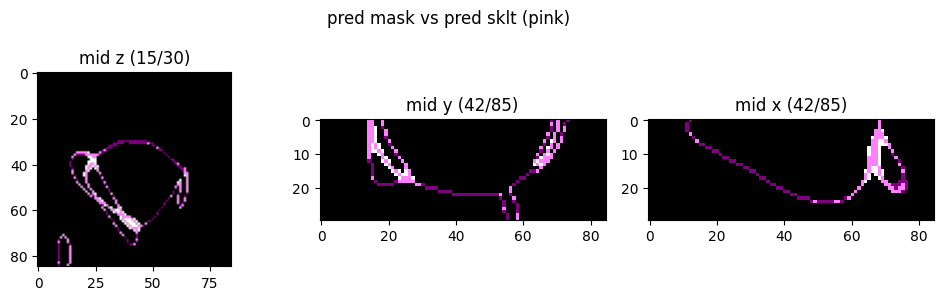

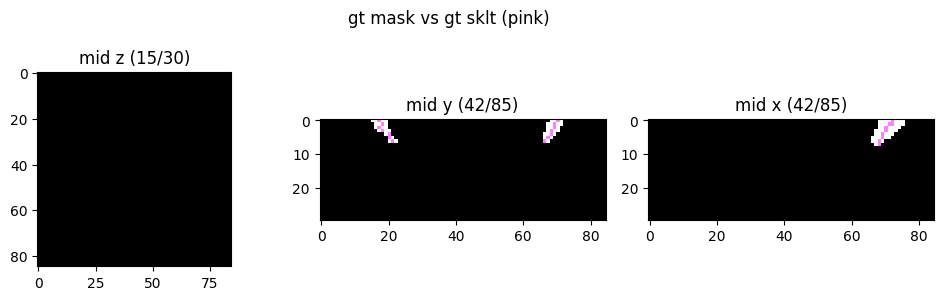

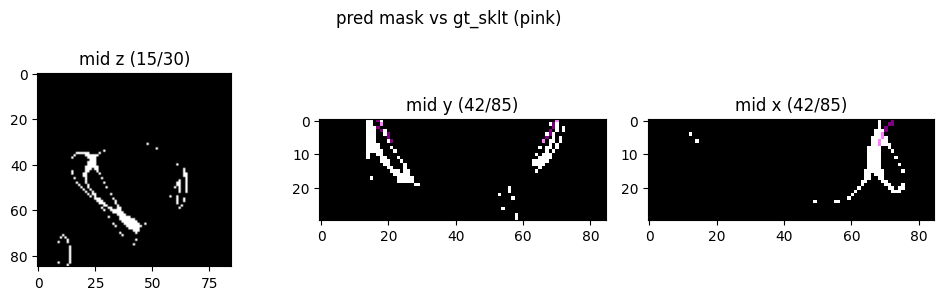

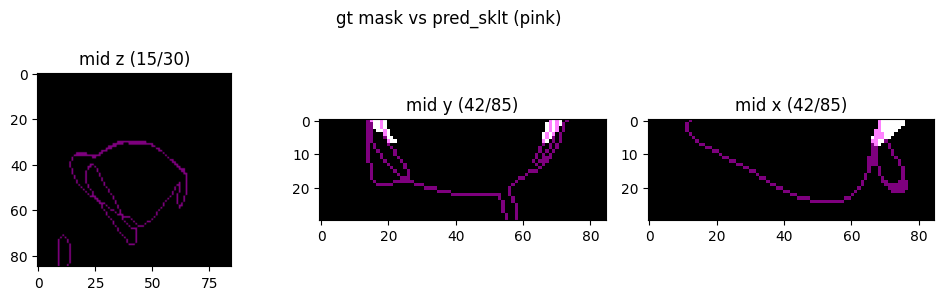

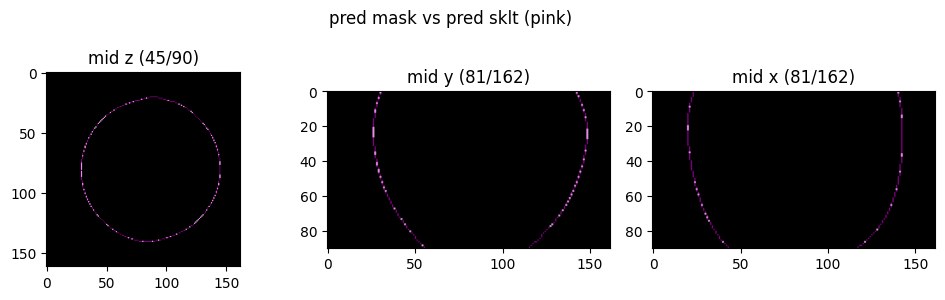

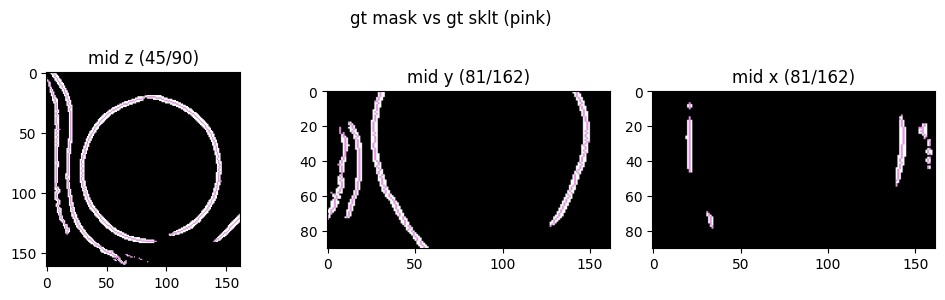

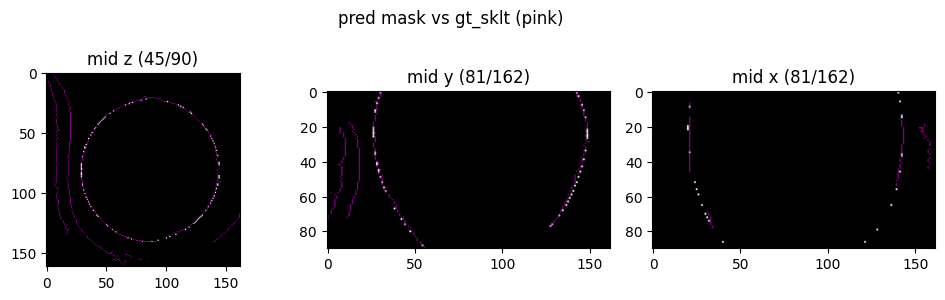

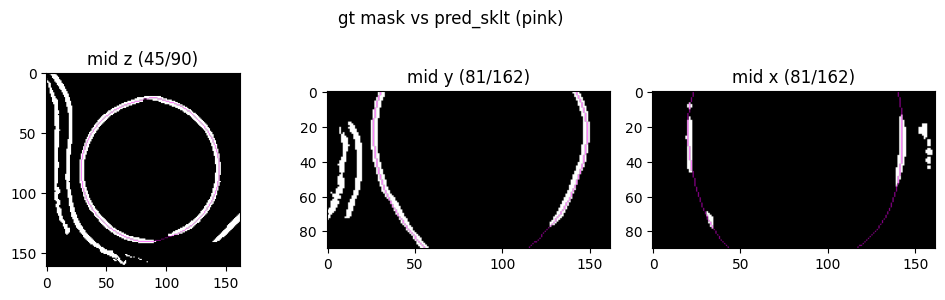

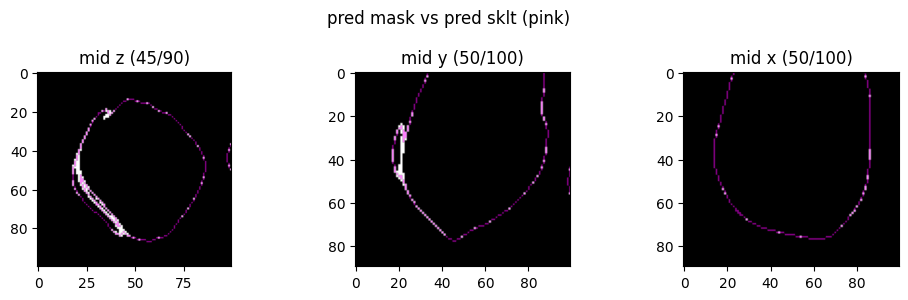

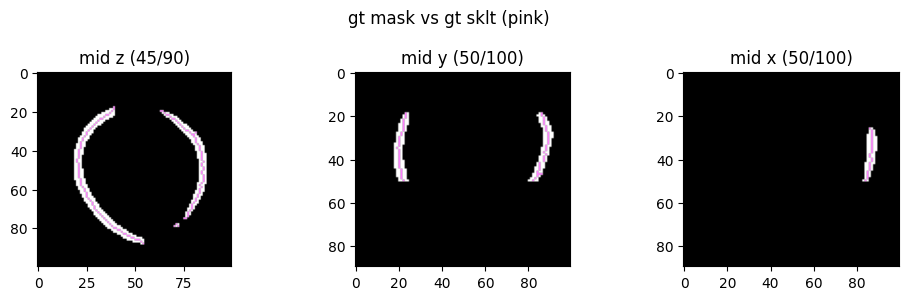

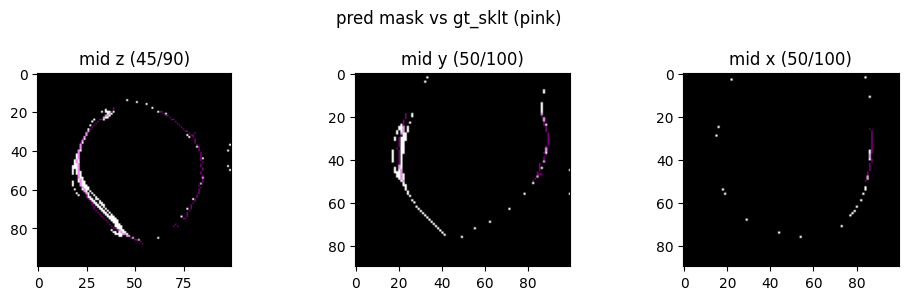

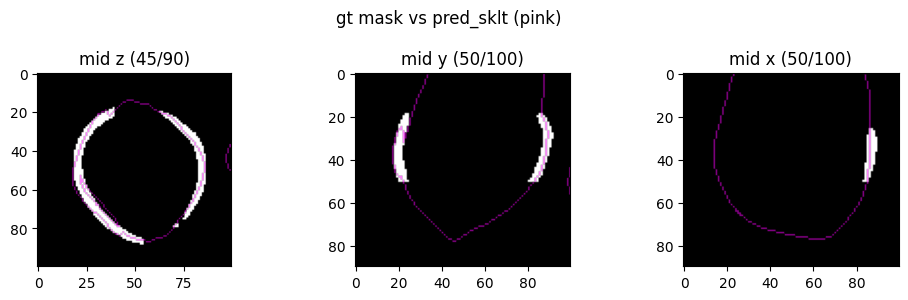

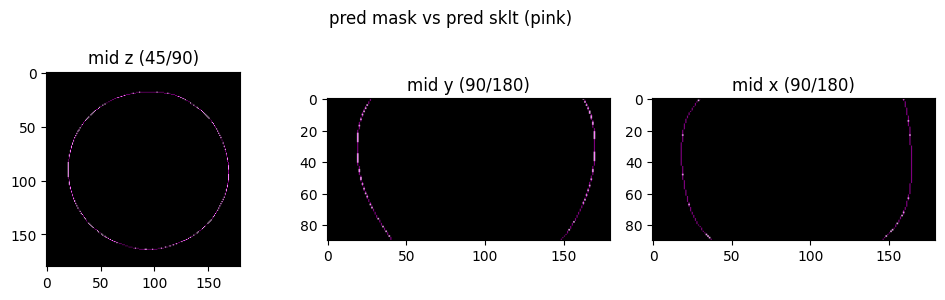

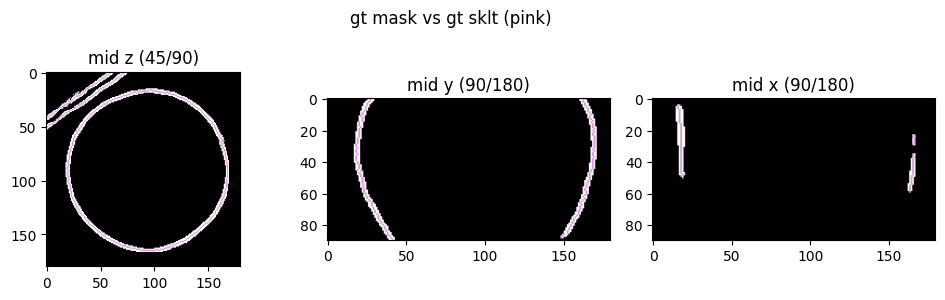

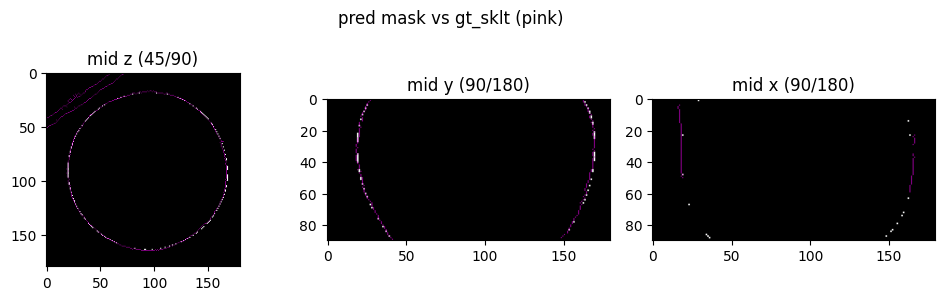

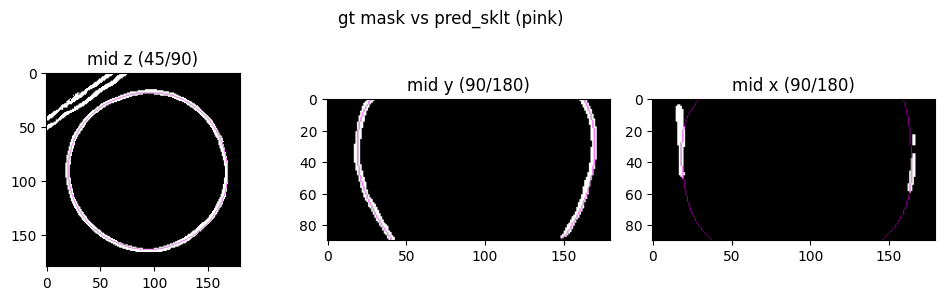

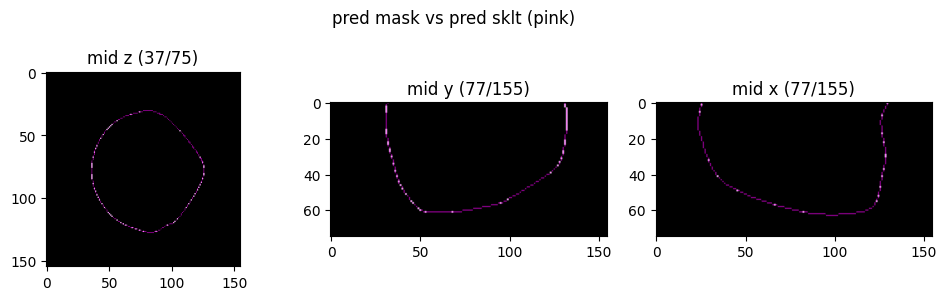

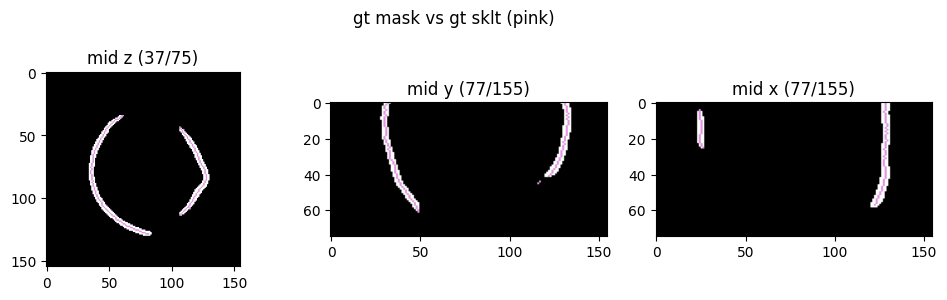

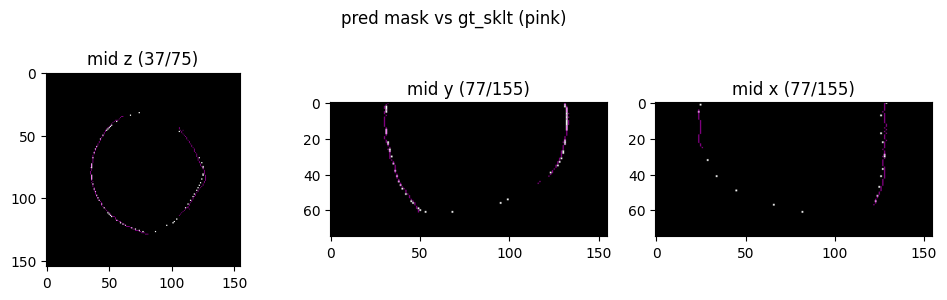

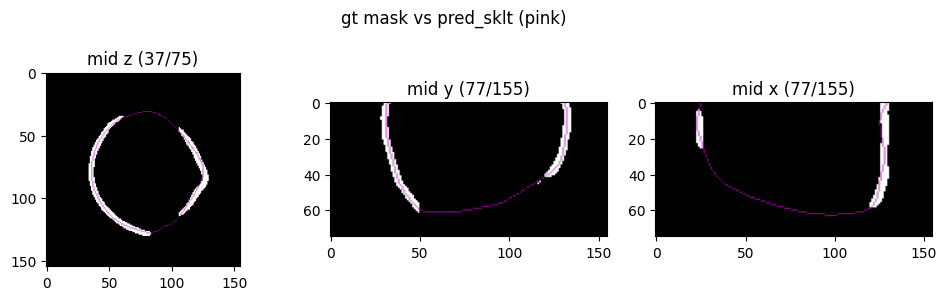

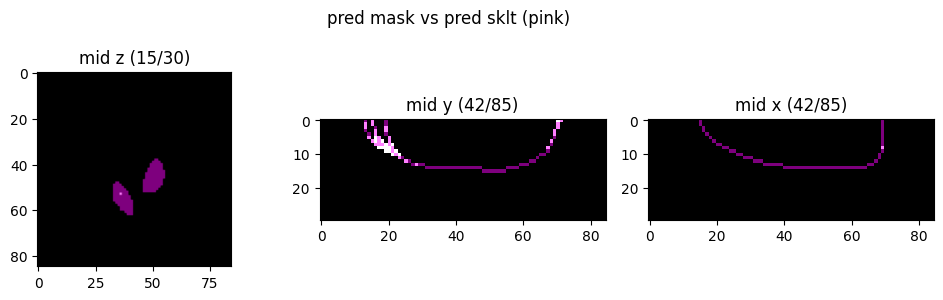

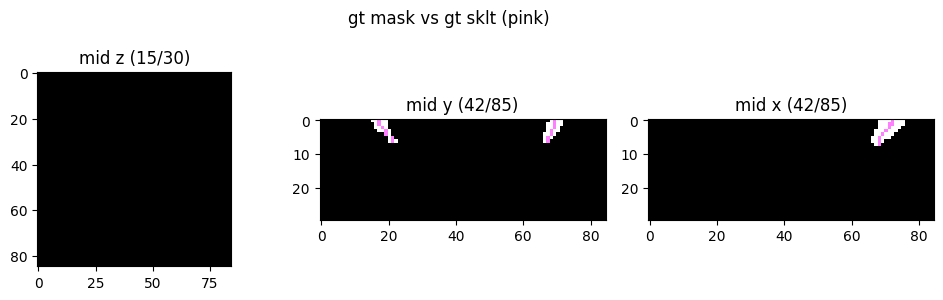

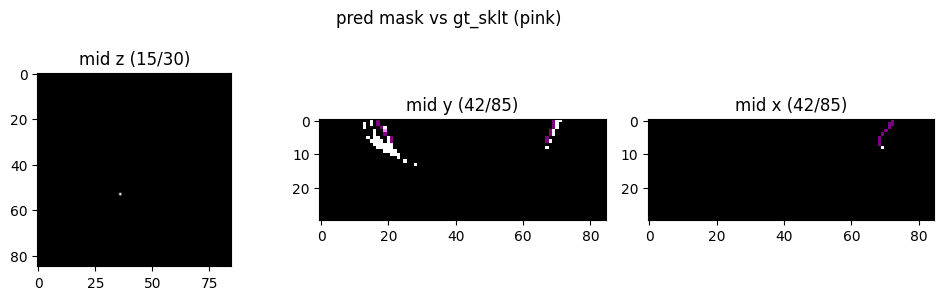

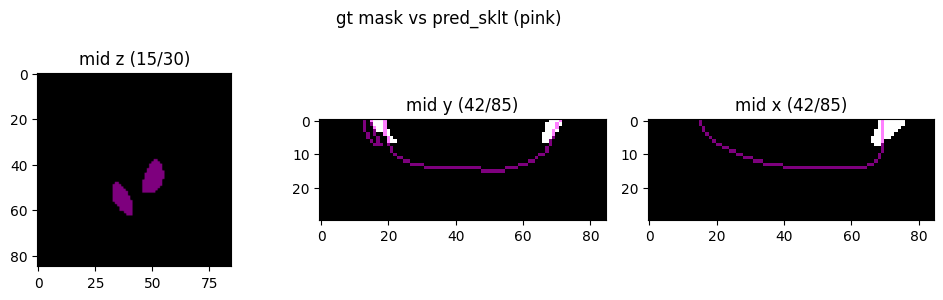

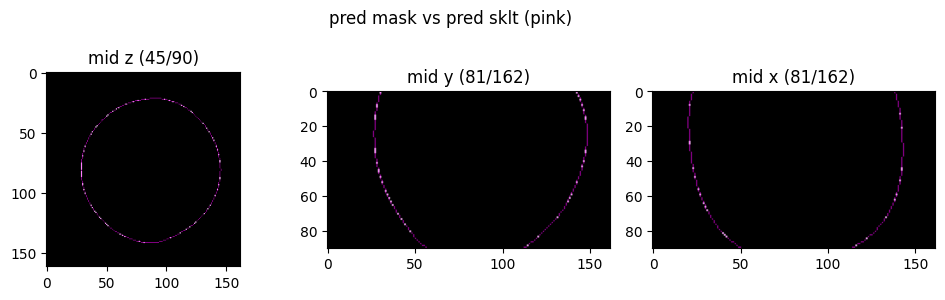

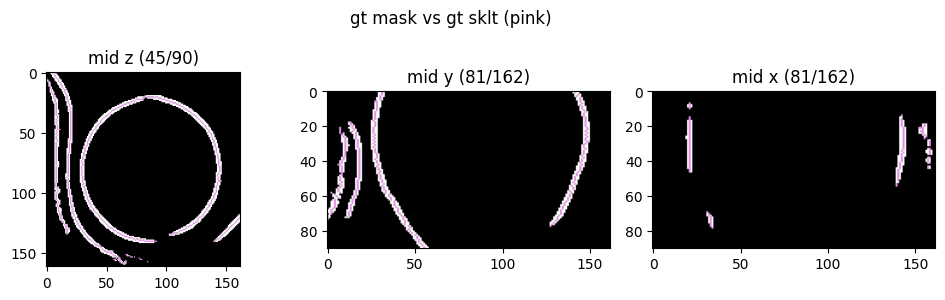

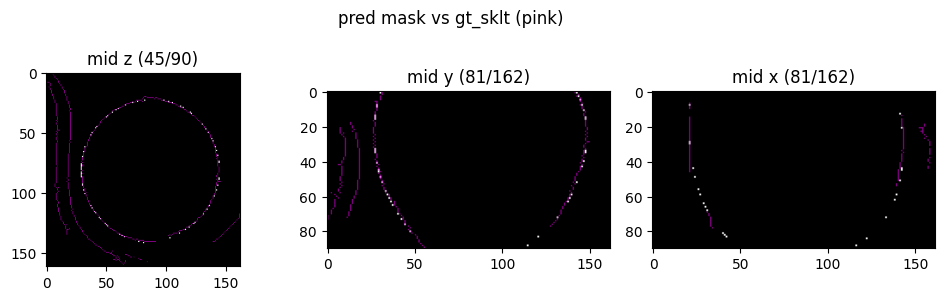

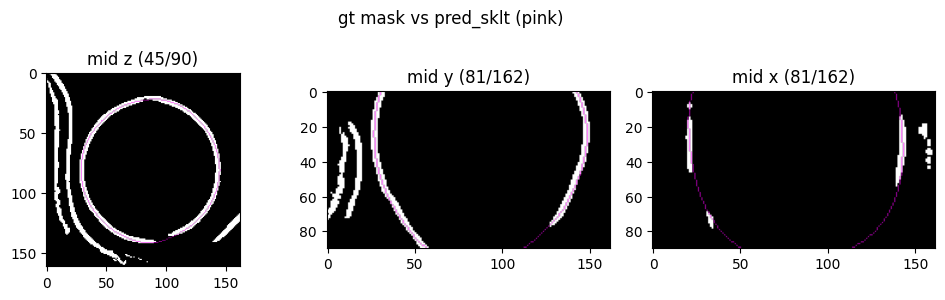

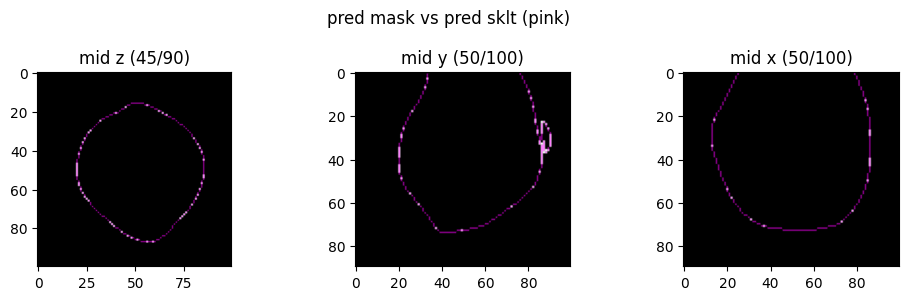

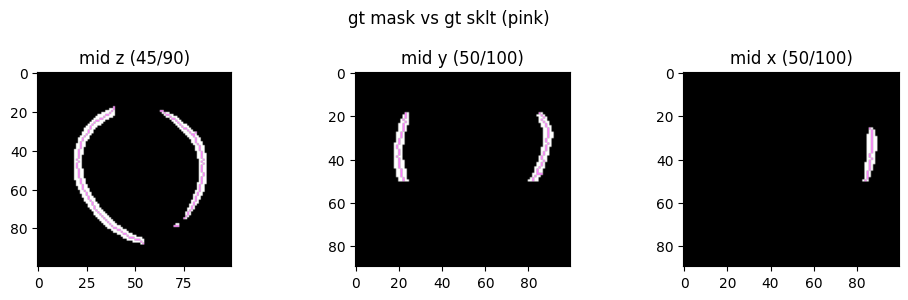

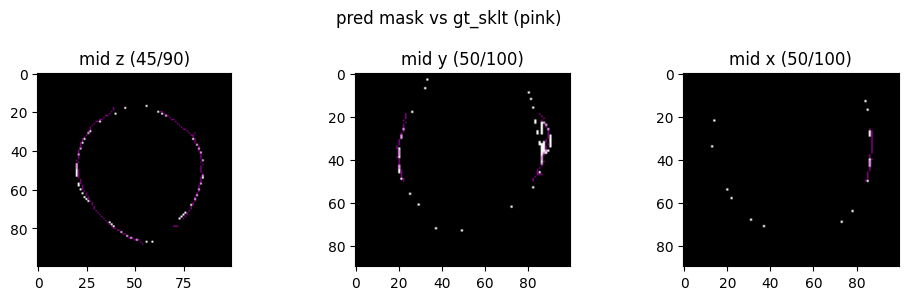

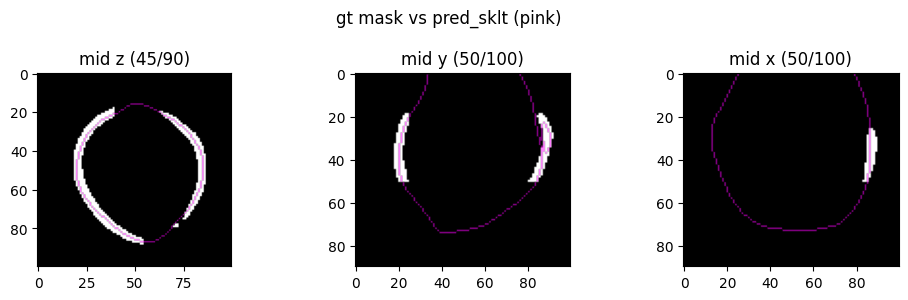

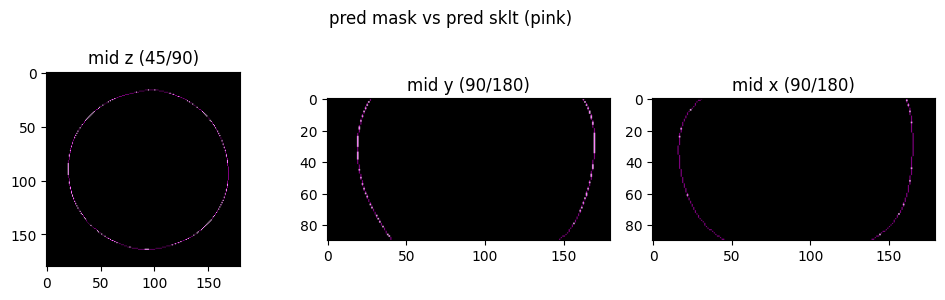

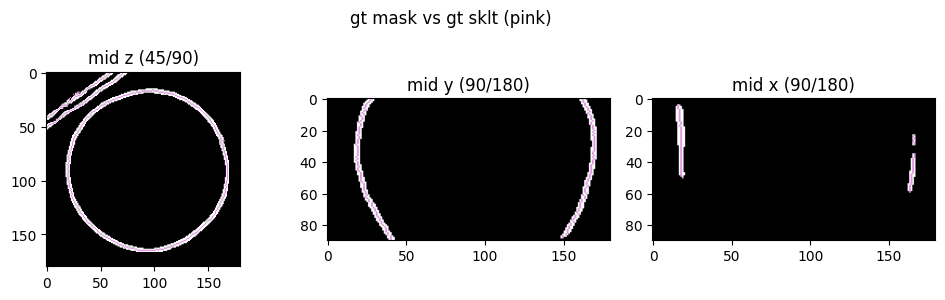

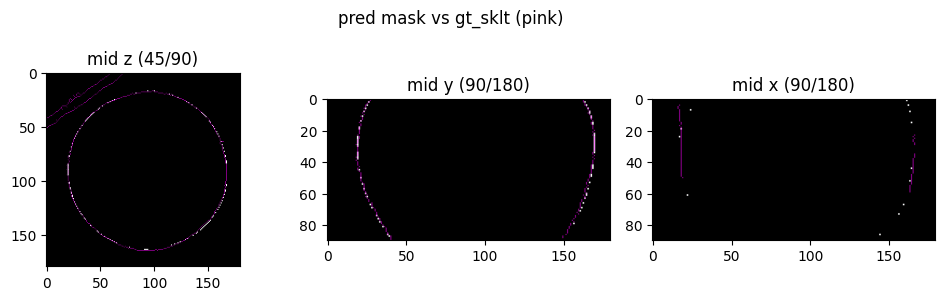

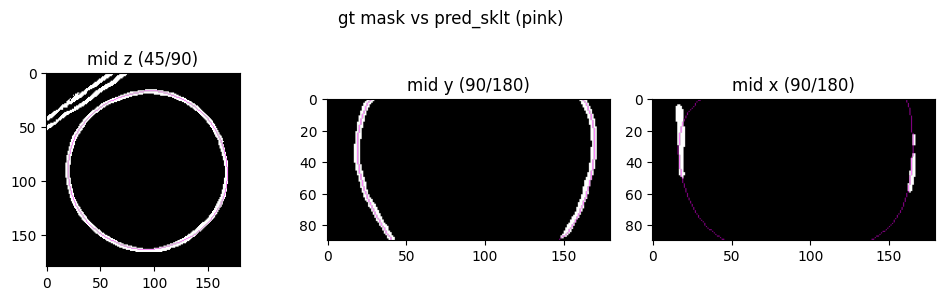

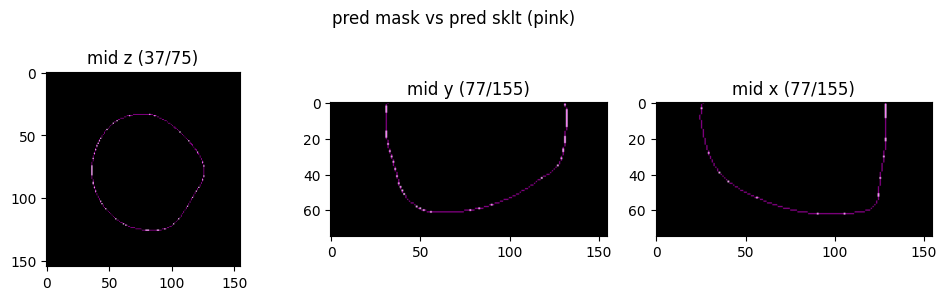

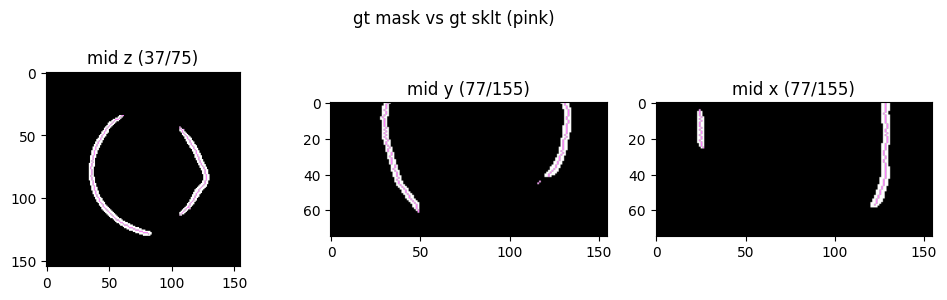

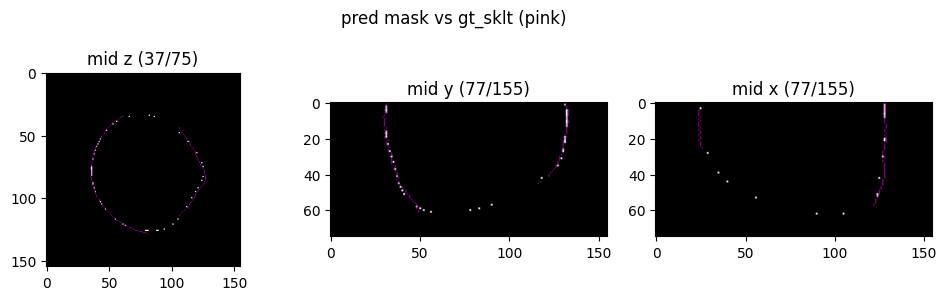

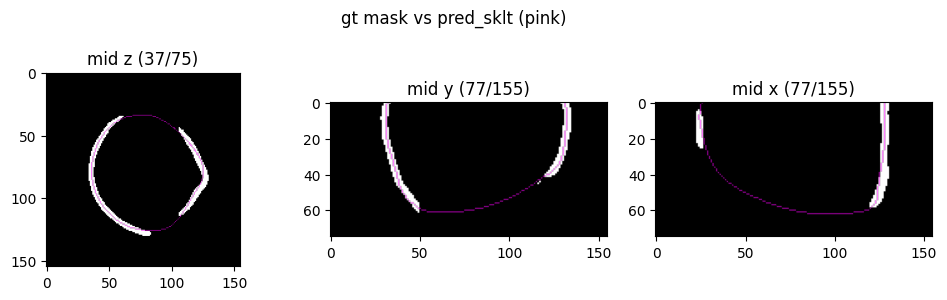

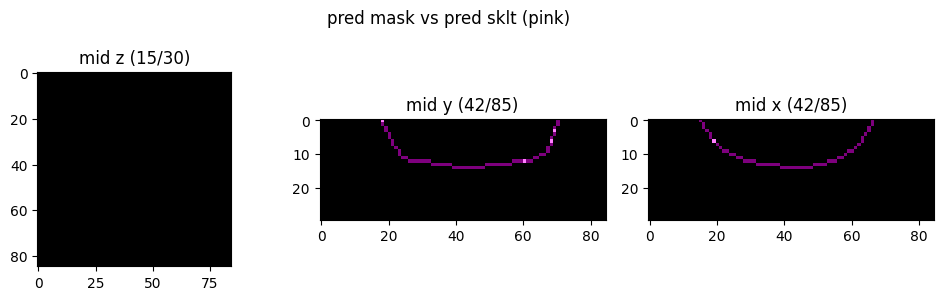

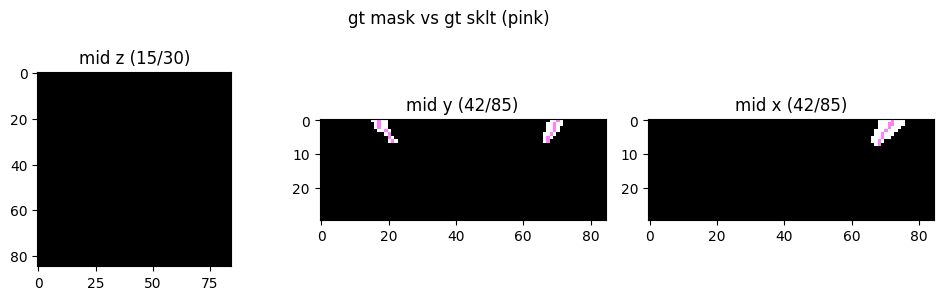

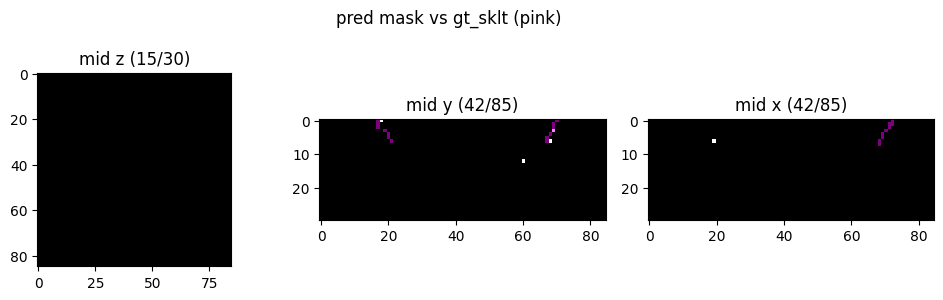

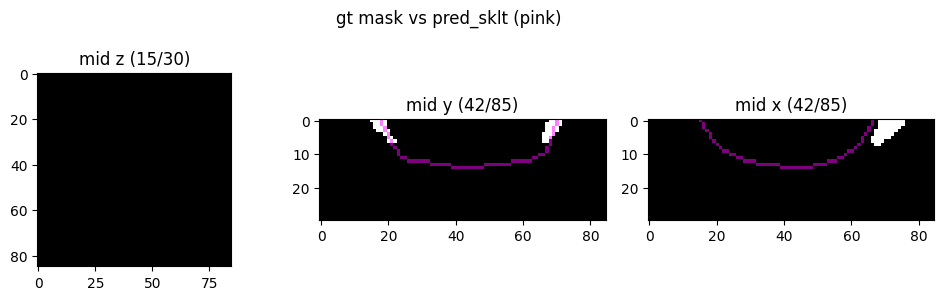

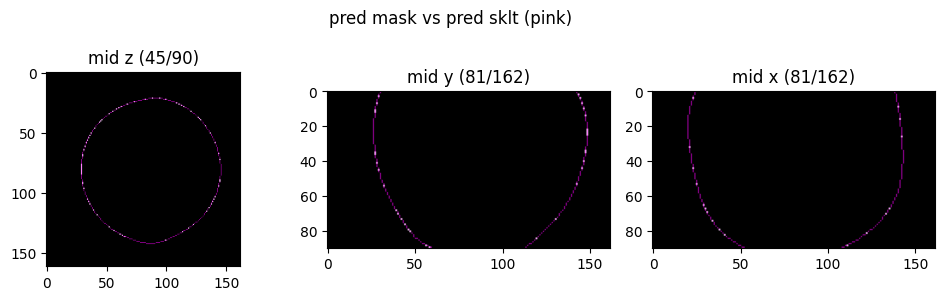

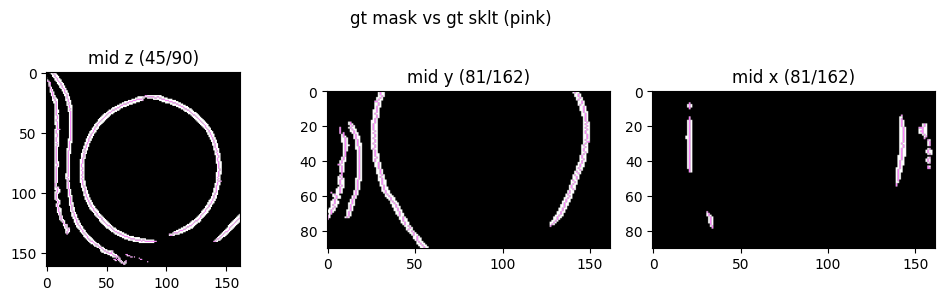

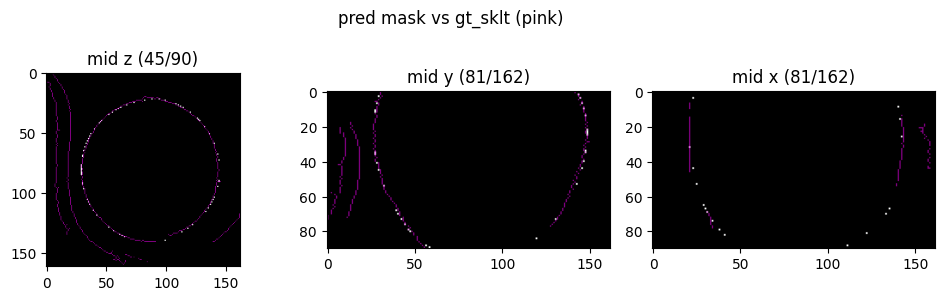

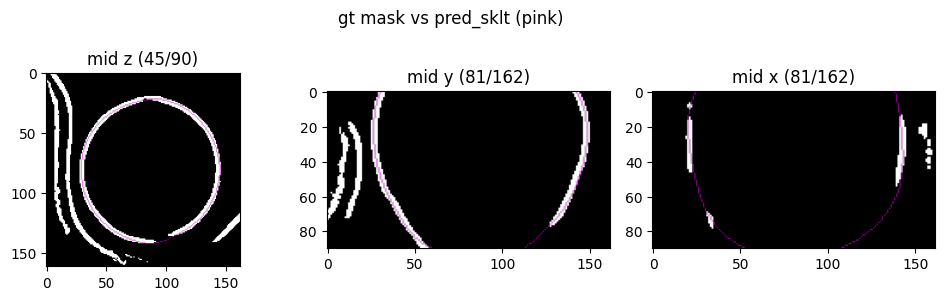

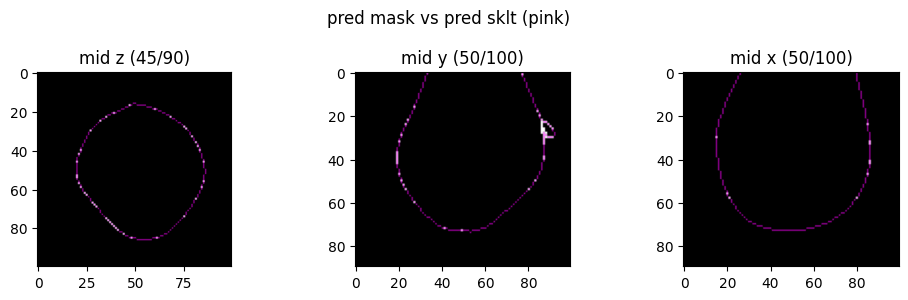

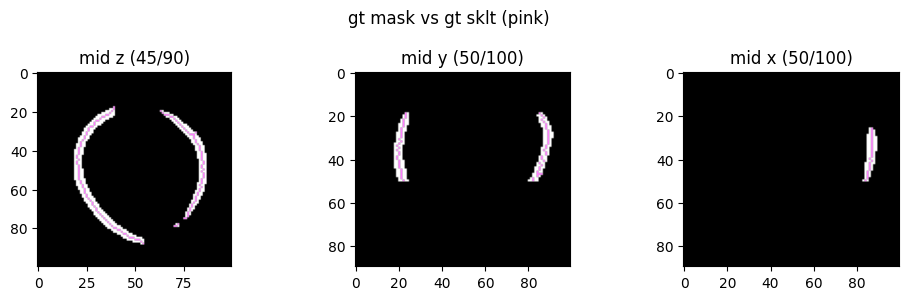

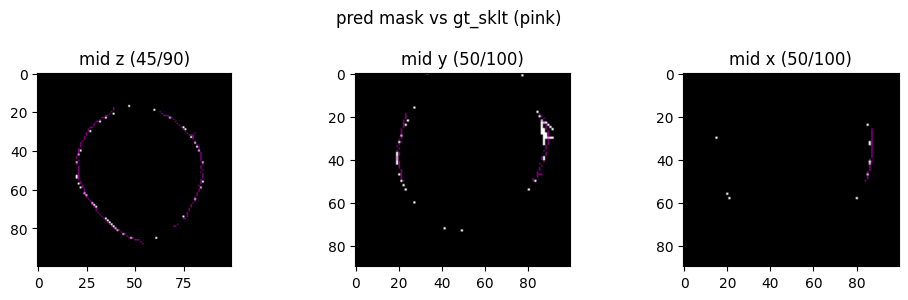

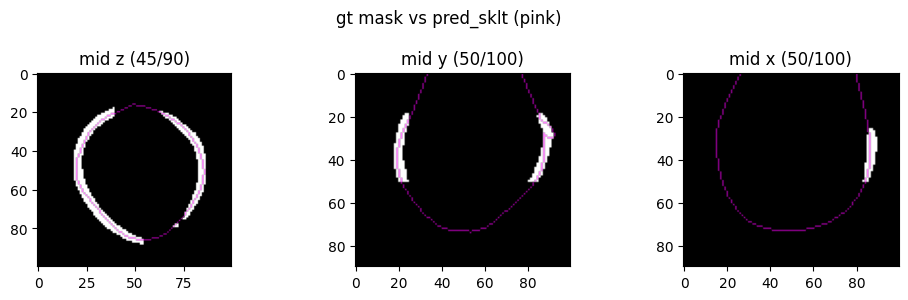

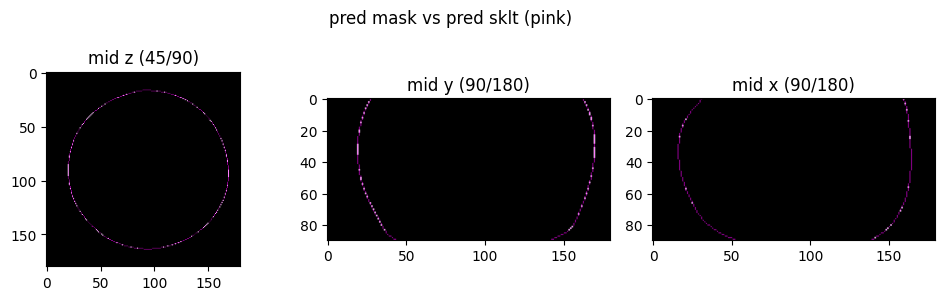

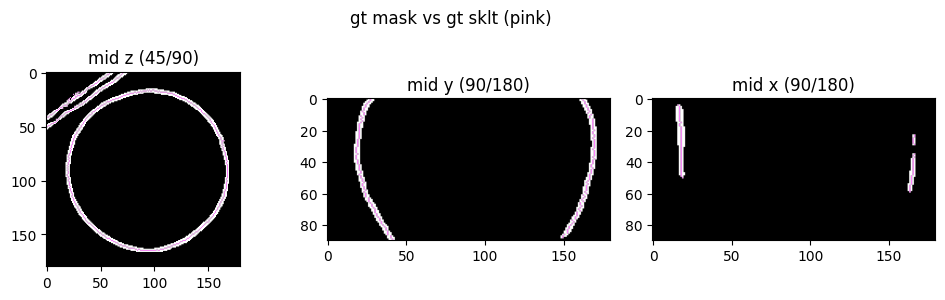

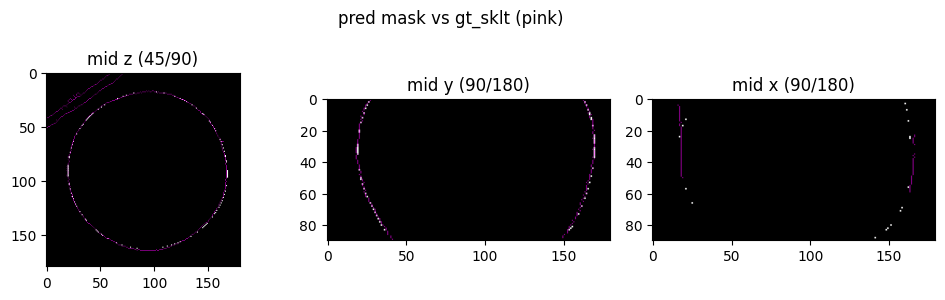

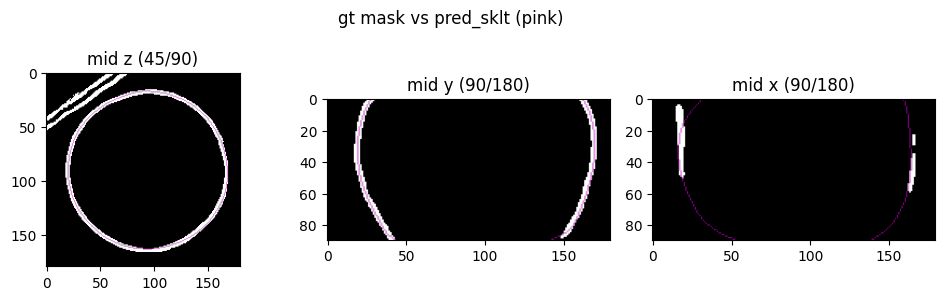

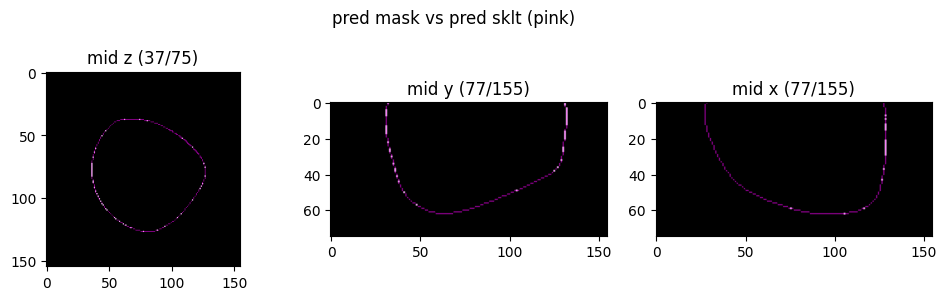

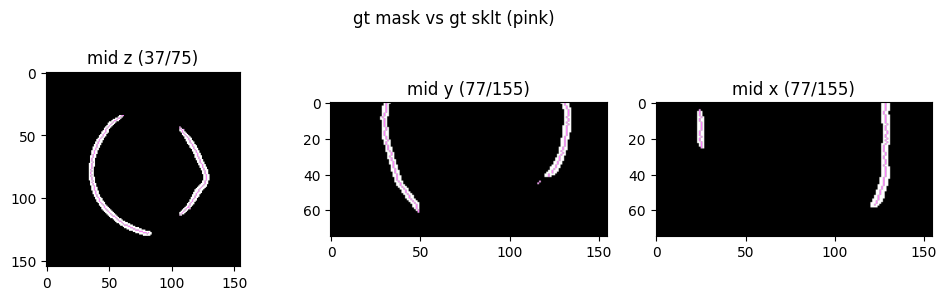

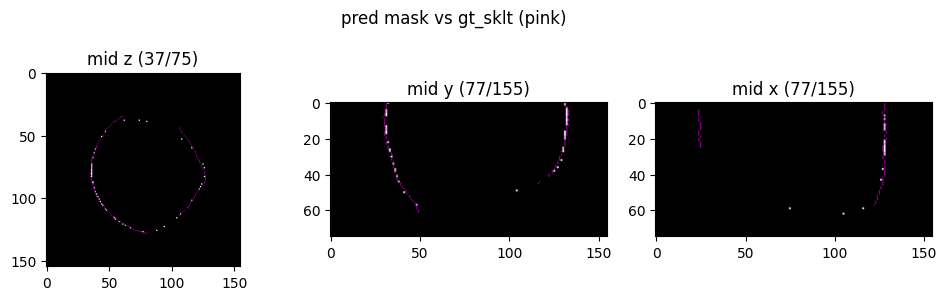

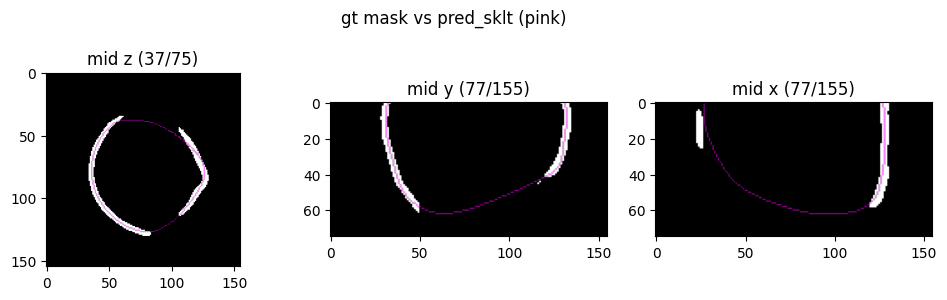

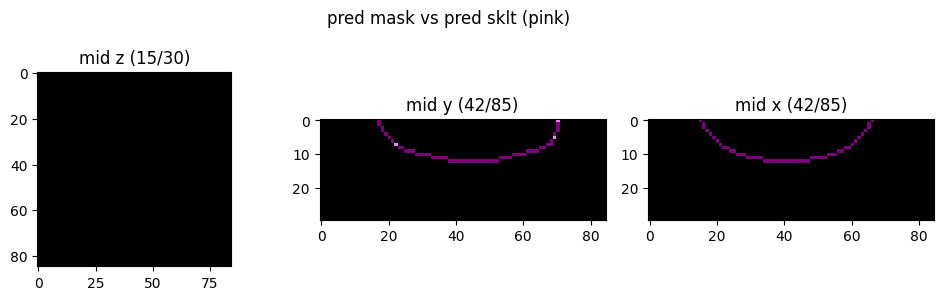

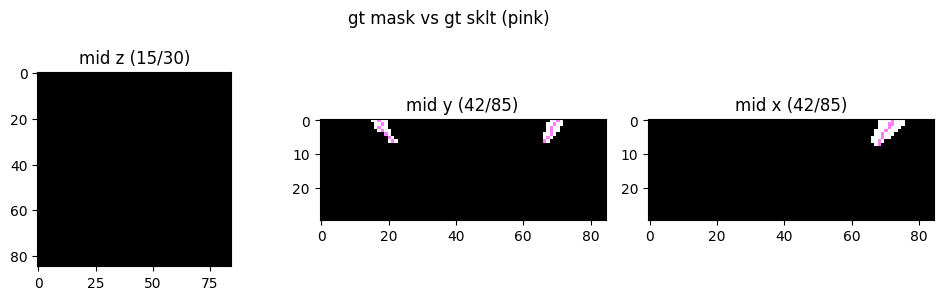

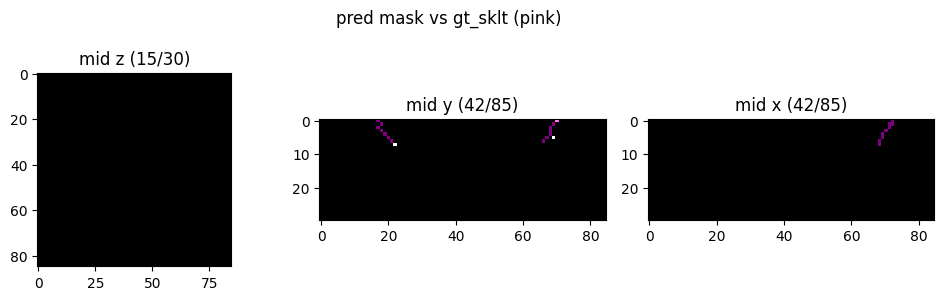

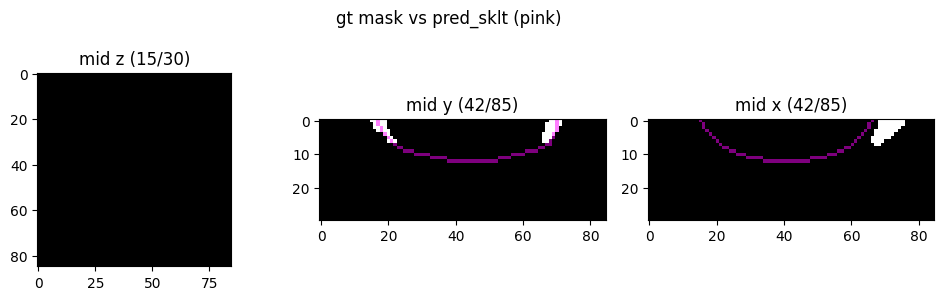

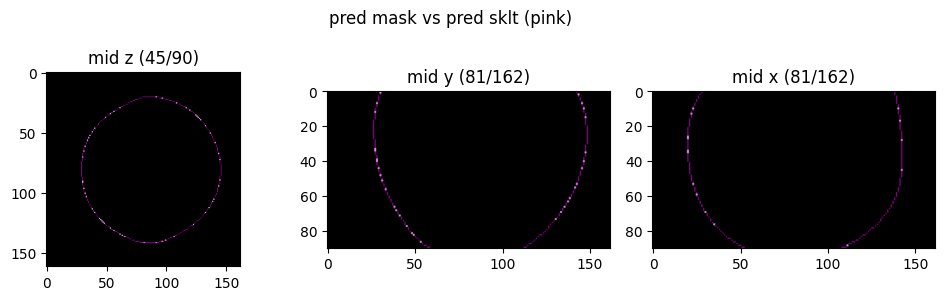

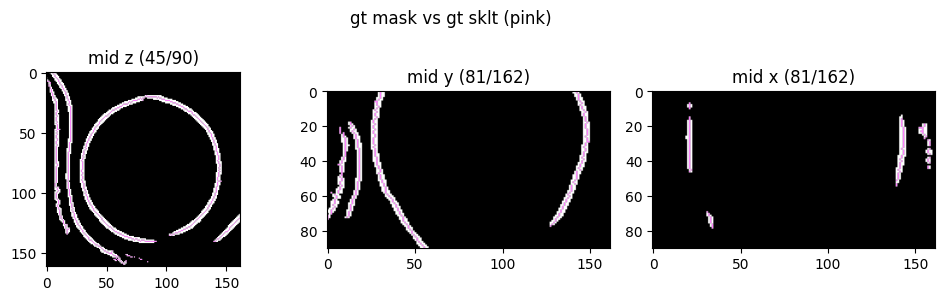

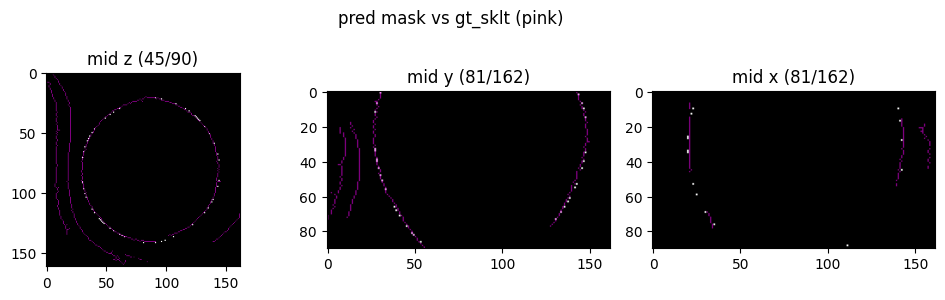

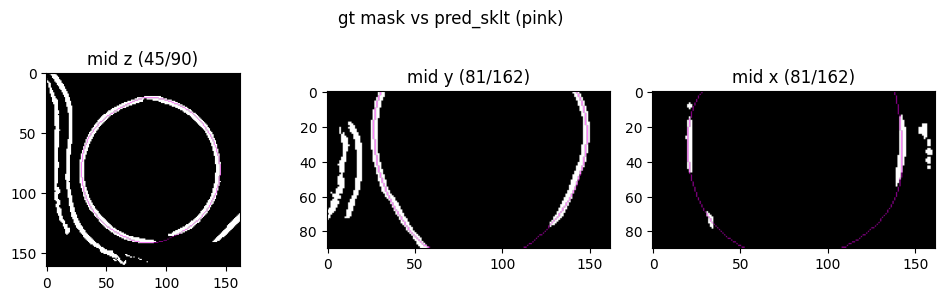

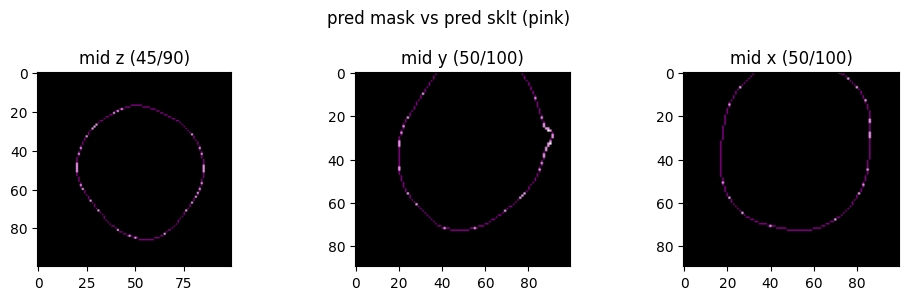

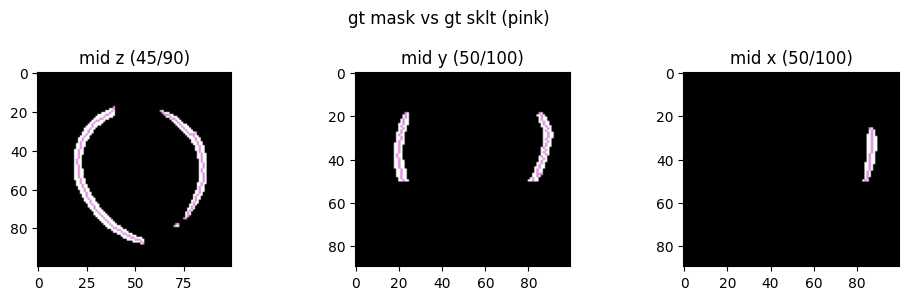

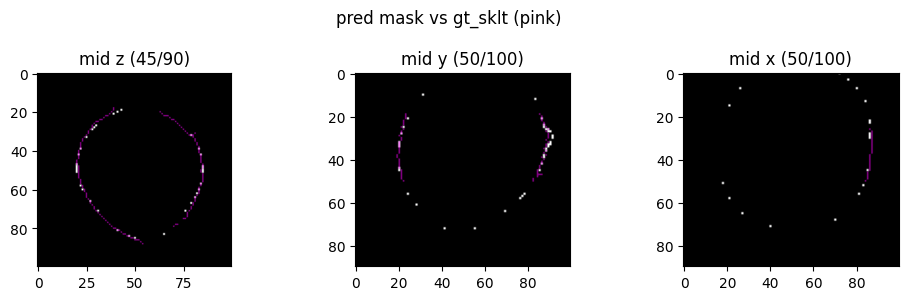

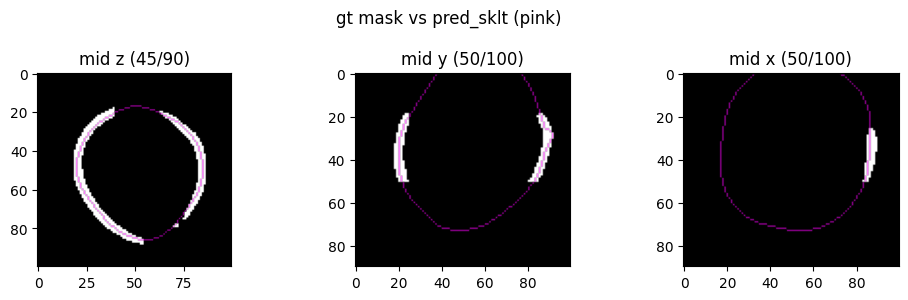

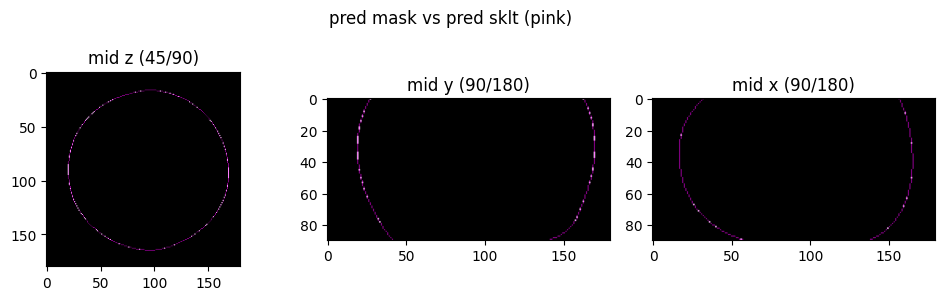

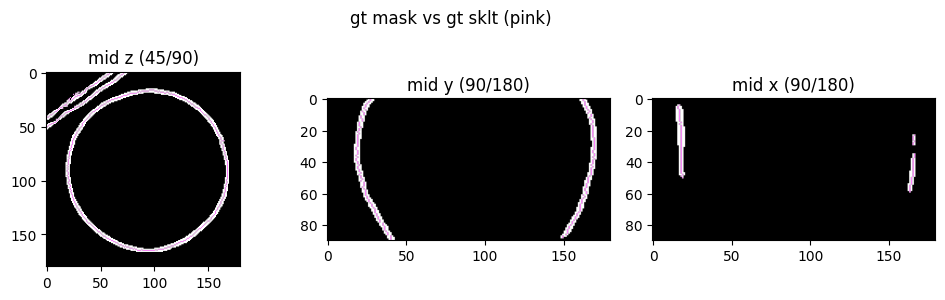

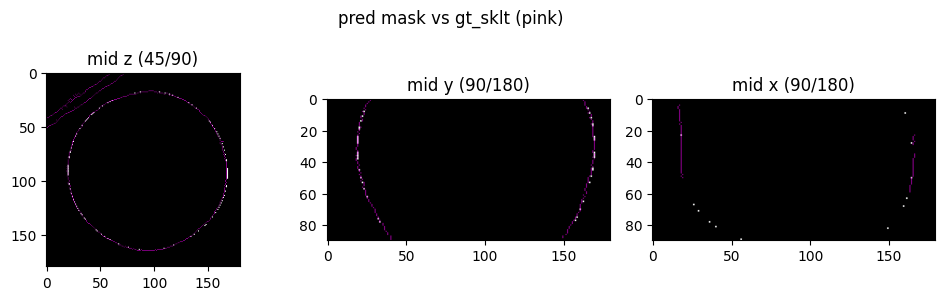

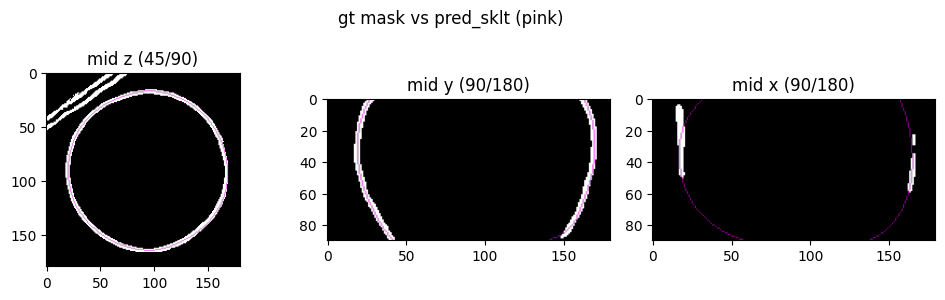

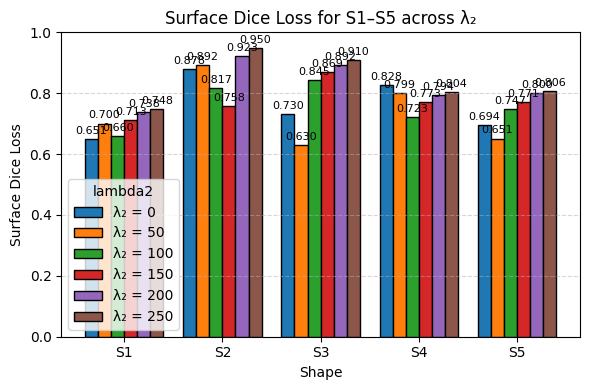

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.analysis import surface_dice  # 함수 이름 확인!
from skimage.morphology import medial_axis

shapes = ["S1", "S2", "S3", "S4", "S5"]

# lambda_2_list, lambda_1, LEARNING_RATE, ori_data_path1~5, shape1~5 등이 이미 정의되어 있다고 가정

# 각 lambda_2마다 S1~S5의 dice loss를 저장할 딕셔너리
dice_results = {}  # key: lambda_2, value: [d1, d2, d3, d4, d5]

for lambda_2 in lambda_2_list:
    checkpoint_dir1 = os.path.abspath(
        f"../outputs/logs/{shape1}_normalized/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{0.05}_Learning_{LEARNING_RATE}/checkpoint"
    )
    checkpoint_dir2 = os.path.abspath(
        f"../outputs/logs/{shape2}_normalized/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{0.05}_Learning_{LEARNING_RATE}/checkpoint"
    )
    checkpoint_dir3 = os.path.abspath(
        f"../outputs/logs/{shape3}_normalized/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{0.05}_Learning_{LEARNING_RATE}/checkpoint"
    )
    checkpoint_dir4 = os.path.abspath(
        f"../outputs/logs/{shape4}_normalized/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{0.05}_Learning_{LEARNING_RATE}/checkpoint"
    )
    checkpoint_dir5 = os.path.abspath(
        f"../outputs/logs/{shape5}_normalized/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{0.05}_Learning_{LEARNING_RATE}/checkpoint"
    )

    # surface_dice 호출 (원래 코드의 surfac_dice 오타 주의!)
    d1 = surface_dice(ori_data_path1, checkpoint_dir1, lambda_1, lambda_2, 20, 80,
                      step=10000, threshold=0.8, band_thickness=0.85)
    d2 = surface_dice(ori_data_path2, checkpoint_dir2, lambda_1, lambda_2, 15, 45,
                      step=10000, threshold=0.8, band_thickness=0.85)
    d3 = surface_dice(ori_data_path3, checkpoint_dir3, lambda_1, lambda_2, 40, 120,
                      step=10000, threshold=0.8, band_thickness=0.85)
    d4 = surface_dice(ori_data_path4, checkpoint_dir4, lambda_1, lambda_2, 60, 90,
                      step=10000, threshold=0.8, band_thickness=0.85)
    d5 = surface_dice(ori_data_path5, checkpoint_dir5, lambda_1, lambda_2, 40, 130,
                      step=10000, threshold=0.8, band_thickness=0.85)

    dice_results[lambda_2] = [d1, d2, d3, d4, d5]

# ----------------- bar plot -----------------
x = np.arange(len(shapes))          # [0, 1, 2, 3, 4]
n_lambda = len(lambda_2_list)
width = 0.8 / n_lambda              # 막대 폭 (0.8 범위 안에서 여러 λ2 막대 배치)

plt.figure(figsize=(6, 4))

for i, lambda_2 in enumerate(lambda_2_list):
    # 각 lambda_2에 대해 x 위치를 약간씩 옆으로 평행이동
    x_pos = x - 0.4 + width/2 + i * width
    bars = plt.bar(x_pos, dice_results[lambda_2],
                   width=width,
                   edgecolor="black",
                   label=f"λ₂ = {lambda_2}")

    # 막대 위에 수치 표시
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.01,
                 f"{height:.3f}",
                 ha='center', va='bottom', fontsize=8)

plt.xticks(x, shapes)
plt.ylim(0, 1)
plt.ylabel("Surface Dice Loss")
plt.xlabel("Shape")
plt.title("Surface Dice Loss for S1–S5 across λ₂")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="lambda2")
plt.tight_layout()
plt.show()


#### 3D Mask vs Prediction

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.ticker import MultipleLocator

def overlay_3d_surfaces_marching_cube(
    pred_mask, gt_mask, overlap_phi_threshold = 0.8, spacing=(1.0, 1.0, 1.0),
    colors=((1, 0, 0, 0.3),   # predicted
            (0, 0, 1, 0.3),   # gt_mask
            (1, 0, 1, 0.3))): # overlay
    """
    pred_mask, gt_mask: (Z, Y, X)
    spacing: (sx, sy, sz)
    """
    assert pred_mask.shape == gt_mask.shape, "Masks must have the same shape (Z, Y, X)."

    # Convert (Z,Y,X) → (X,Y,Z)
    pred_mask = pred_mask.transpose(2, 1, 0)
    gt_mask   = gt_mask.transpose(2, 1, 0)

    X, Y, Z = pred_mask.shape
    sx, sy, sz = spacing

    # Extract surfaces
    pred_verts, pred_faces, _, _ = marching_cubes(pred_mask.astype(np.float32),
                                                  level=0.0, spacing=(sx, sy, sz))
    gt_verts, gt_faces, _, _ = marching_cubes(gt_mask.astype(np.float32),
                                              level=0.9, spacing=(sx, sy, sz))

    # Overlap mask
    overlap = np.logical_and(abs(pred_mask) > overlap_phi_threshold, gt_mask > 0.5).astype(np.float32)
    overlap_present = overlap.any()
    if overlap_present:
        overlap_verts, overlap_faces, _, _ = marching_cubes(overlap, level=0.5, spacing=(sx, sy, sz))

    # ===== Plot =====
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    # predicted
    pred_mesh = Poly3DCollection(pred_verts[pred_faces],
                                 alpha=colors[0][3],
                                 facecolor=colors[0][:3],
                                 edgecolor='none')
    ax.add_collection3d(pred_mesh)

    # gt_mask
    gt_mesh = Poly3DCollection(gt_verts[gt_faces],
                               alpha=colors[1][3],
                               facecolor=colors[1][:3],
                               edgecolor='none')
    ax.add_collection3d(gt_mesh)

    # overlay
    if overlap_present:
        overlay_mesh = Poly3DCollection(overlap_verts[overlap_faces],
                                        alpha=colors[2][3],
                                        facecolor=colors[2][:3],
                                        edgecolor='none')
        ax.add_collection3d(overlay_mesh)

    # ===== Legend patches =====
    patch_pred = Patch(facecolor=colors[0][:3], alpha=colors[0][3], label="predicted")
    patch_gt   = Patch(facecolor=colors[1][:3], alpha=colors[1][3], label="gt_mask")
    
    patches = [patch_pred, patch_gt]

    if overlap_present:
        patch_overlay = Patch(facecolor=colors[2][:3], alpha=colors[2][3], label="overlay")
        patches.append(patch_overlay)

    ax.legend(handles=patches, loc="upper right", fontsize=12)

    # Axes
    ax.set_xlim(0, X * sx)
    ax.set_ylim(0, Y * sy)
    ax.set_zlim(0, Z * sz)
    ax.zaxis.set_major_locator(MultipleLocator(15))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z", labelpad=10)

    ax.set_box_aspect((X*sx, Y*sy, Z*sz))

    plt.tight_layout()
    plt.show()


In [61]:
phi_pred = np.where(abs(phi_zyx) < 0.5, 1, 0)
mask_data = np.where(mask_data > 0, 1, 0)

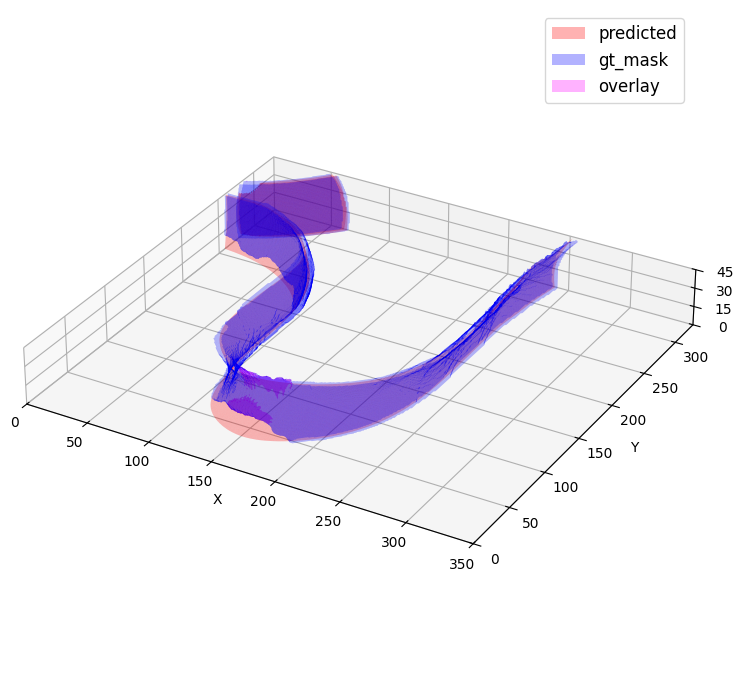

In [14]:
overlay_3d_surfaces_marching_cube(phi_zyx, mask_data)

In [ ]:
import matplotlib.pyplot as plt

def plot_binary_voxels(pred_data, gt_mask):
    Z, Y, X = gt_mask.shape  # 데이터 크기 추출

    fig = plt.figure(figsize=(8,7))
    ax = fig.add_subplot(111, projection="3d")

    # GT mask
    ax.voxels(gt_mask == 1,
              facecolors='blue', edgecolor='k', alpha=0.3)

    # predicted mask
    ax.voxels(abs(pred_data) < 0.5,
              facecolors='red', edgecolor='k', alpha=0.3)

    # 축 라벨
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # 원래 배열 크기 비율로 맞추기
    ax.set_box_aspect((X, Y, Z))  # (X:Y:Z 비율)

    plt.tight_layout()
    plt.show()

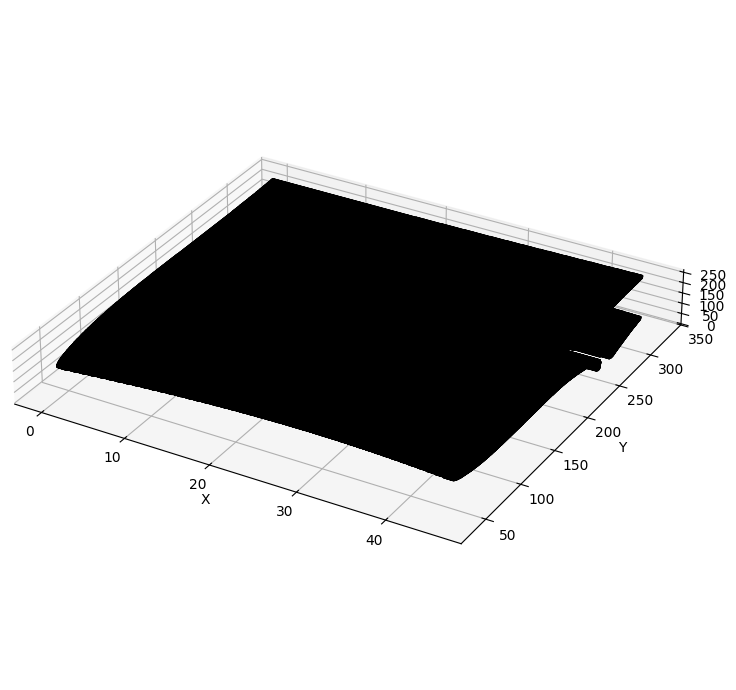

In [17]:
plot_binary_voxels(phi_zyx, mask_data)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_binary_voxels(pred_data, gt_mask):
    # ------------------------
    # 1. (Z,Y,X) → (X,Y,Z) 로 transpose
    # ------------------------
    gt_xyz   = gt_mask.transpose(2,1,0)         # (X,Y,Z)
    pred_xyz = (np.abs(pred_data) < 0.5).transpose(2,1,0)  # (X,Y,Z)

    vol = gt_xyz | pred_xyz   # 전체 voxel 존재 여부 map

    # facecolor 배열 준비
    facecolors = np.zeros(vol.shape + (4,), dtype=float)

    # 색 지정: pred=red, gt=blue, overlap=purple
    pred_only = pred_xyz & ~gt_xyz
    gt_only   = gt_xyz & ~pred_xyz
    both      = pred_xyz & gt_xyz

    facecolors[pred_only] = (1, 0, 0, 0.4)   # red
    facecolors[gt_only]   = (0, 0, 1, 0.4)   # blue
    facecolors[both]      = (1, 0, 1, 0.6)   # purple

    # ------------------------
    # 2. Plot
    # ------------------------
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection="3d")

    ax.voxels(vol, facecolors=facecolors, edgecolor='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # aspect ratio 유지
    X, Y, Z = vol.shape
    ax.set_box_aspect((X, Y, Z))

    plt.tight_layout()
    plt.show()


In [ ]:
plot_binary_voxels(phy_zyx, mask_data)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D  # noqa


def overlay_3d_voxels(
    phi_zyx,
    gt_mask,
    phi_thresh=0.5,
    spacing=(1.0, 1.0, 1.0),
    colors=((1, 0, 0, 0.3),   # predicted only
            (0, 0, 1, 0.3),   # gt only
            (1, 0, 1, 0.5)),  # overlap
):
    """
    phi_zyx : (Z, Y, X) 예측 φ
    gt_mask : (Z, Y, X) 0/1 binary GT
    phi_thresh : pred_mask = (|phi| > phi_thresh) 로 정의 (원하면 < 로 바꿔도 됨)
    spacing : (dz, dy, dx)
    """

    assert phi_zyx.shape == gt_mask.shape
    Z, Y, X = phi_zyx.shape
    dz, dy, dx = spacing

    # -------- 1) voxel mask들 만들기 --------
    pred_mask = (np.abs(phi_zyx) > phi_thresh)      # 네가 말한 정의
    gt_mask_bool = gt_mask > 0.5

    pred_only = pred_mask & ~gt_mask_bool
    gt_only   = ~pred_mask & gt_mask_bool
    both      = pred_mask & gt_mask_bool

    # 합쳐서 하나의 volume + facecolors 생성 (ax.voxels용)
    vol = pred_only | gt_only | both

    # facecolors 배열 (nx,ny,nz,4)
    facecolors = np.zeros(vol.shape + (4,), dtype=float)

    r_pred, g_pred, b_pred, a_pred = colors[0]
    r_gt,   g_gt,   b_gt,   a_gt   = colors[1]
    r_ov,   g_ov,   b_ov,   a_ov   = colors[2]

    facecolors[pred_only] = (r_pred, g_pred, b_pred, a_pred)
    facecolors[gt_only]   = (r_gt,   g_gt,   b_gt,   a_gt)
    facecolors[both]      = (r_ov,   g_ov,   b_ov,   a_ov)

    # -------- 2) Matplotlib의 voxels는 (X,Y,Z) 순서를 기대하므로 transpose --------
    vol_xyz        = vol.transpose(2, 1, 0)              # (X,Y,Z)
    facecolors_xyz = facecolors.transpose(2, 1, 0, 3)    # (X,Y,Z,4)

    # -------- 3) 플롯 --------
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.voxels(vol_xyz, facecolors=facecolors_xyz, edgecolor="none")

    # 축/비율 (spacing 반영해서 aspect만 맞춰줌)
    ax.set_xlim(0, X * dx)
    ax.set_ylim(0, Y * dy)
    ax.set_zlim(0, Z * dz)
    ax.set_box_aspect((X * dx, Y * dy, Z * dz))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # legend (pred / gt / overlap)
    patches = [
        Patch(facecolor=colors[0][:3], alpha=colors[0][3], label="pred_only"),
        Patch(facecolor=colors[1][:3], alpha=colors[1][3], label="gt_only"),
        Patch(facecolor=colors[2][:3], alpha=colors[2][3], label="overlap"),
    ]
    ax.legend(handles=patches, loc="upper right")

    plt.tight_layout()
    plt.show()


In [ ]:
overlay_3d_voxels(phi_zyx, mask_data, phi_thresh=0.5)

#### Napari

In [ ]:
viewer = napari.Vie_marching_cubewer()
viewer.add_image(phi_pred.astype(np.float32), name="Predicted Mask", colormap="twilight", blending="additive", opacity=0.5)
viewer.add_image(ori_data.astype(np.float32), name="Original data", colormap="twilight", blending="additive", opacity=0.5)
viewer.add_image(mask_data.astype(np.float32), name="GT Mask", colormap="twilight", blending="additive", opacity=0.5)
napari.run()